<a href="https://colab.research.google.com/github/hyeonji826/AI/blob/gen-vision/art_Yolov3_%EB%85%B8%ED%98%84%EC%A7%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, shutil, json, math, random, heapq, time
import numpy as np
import cv2
import csv
import statistics
import albumentations as A
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from pathlib import Path
from typing import List, Tuple, Dict
from torch.amp import autocast, GradScaler

In [ ]:
root = "/content/data/Sample"
img_root = f"{root}/01.원천데이터"      # .jpg
lab_root = f"{root}/02.라벨링데이터"    # .json

dataset_root = "/content/dataset"
images_root = f"{dataset_root}/images"  # .jpg (전처리 후)
labels_root = f"{dataset_root}/labels"  # .txt

splits = ["train", "val"]

In [ ]:
!apt-get -y install fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,833 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 126380 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


### 데이터 준비

In [ ]:
# 초기화 후 CP949로 해제
!rm -rf /content/data && mkdir -p /content/data
!unzip -qq -O CP949 "/content/drive/MyDrive/Colab Notebooks/Python_colab/Web Service/생성형 AI/data/art.zip" -d /content/data

In [ ]:
import glob
from pathlib import Path
random.seed(2025)

for split in ["train", "val"]:
    os.makedirs(f"{dataset_root}/images/{split}", exist_ok=True)
    os.makedirs(f"{dataset_root}/labels/{split}", exist_ok=True)

# 각 클래스 폴더 순회
classes = os.listdir(img_root)
for cls in classes:
    img_paths = sorted(glob.glob(f"{img_root}/{cls}/*.jpg"))
    lab_paths = sorted(glob.glob(f"{lab_root}/{cls}/*.json"))

    # 이름 기준 매칭
    pairs = [(i, l) for i, l in zip(img_paths, lab_paths) if Path(i).stem == Path(l).stem]
    random.shuffle(pairs)

    n = len(pairs)
    n_train = int(n*0.8)
    n_val   = n - n_train   # 나머지 전부 val

    split_data = {
        "train": pairs[:n_train],
        "val":   pairs[n_train:]
    }

    # 복사
    for split, items in split_data.items():
        for imgf, labf in items:
            shutil.copy(imgf, f"{dataset_root}/images/{split}/{Path(imgf).name}")
            shutil.copy(labf, f"{dataset_root}/labels/{split}/{Path(labf).name}")

print("데이터셋 분리 완료 ✅ (train=0.8, val=0.2)")

데이터셋 분리 완료 ✅ (train=0.8, val=0.2)


### 데이터 분석

1. 클래스/박스 분포와 사이즈 특성 파악
2. 큰 객체 면적 범위와 비율 파악
3. 앵커 후보 추출(K-means, IoU 거리) & 계층 군집 시각화
4. YOLOv3 3-head(Strides 8/16/32)에 맞춘 앵커 매핑 기준 정리

In [ ]:
def convert_split_jsons(split: str, labels_root: str, class_to_id: dict):
    """
    split: "train" / "val"
    labels_root: dataset_root/labels
    class_to_id: {"cls_name": id}
    """
    split_dir = Path(labels_root) / split
    json_paths = sorted(glob.glob(str(split_dir / "*.json")))

    stats_rows = []
    for jp in json_paths:
        with open(jp, "r", encoding="utf-8") as f:
            J = json.load(f)

        # 해상도
        W,H = None,None
        if "meta" in J and "img_resolution" in J["meta"]:
            W,H = map(int, J["meta"]["img_resolution"].lower().split("x"))

        stem = Path(jp).stem
        yolo_txt = split_dir / f"{stem}.txt"
        lines = []

        for b in J.get("annotations", {}).get("bbox", []):
            lab = str(b.get("label", "")).strip()
            if lab not in class_to_id: continue
            cid = class_to_id[lab]
            x,y,w,h = [float(b[k]) for k in ("x","y","w","h")]
            cx = (x + w/2.0) / W
            cy = (y + h/2.0) / H
            nw, nh = w/W, h/H
            lines.append(f"{cid} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

            stats_rows.append({
                "split": split,
                "cls_name": lab,
                "cls_id": cid,
                "area_norm": nw*nh,
                "aspect": (nw/nh) if nh>0 else np.nan
            })

        if lines:
            with open(yolo_txt, "w", encoding="utf-8") as f:
                f.write("\n".join(lines))

    return pd.DataFrame(stats_rows)

# 전체 클래스 사전 만들기 (train/val/test 합쳐서)
all_jsons = glob.glob(str(Path(labels_root)/"*/*.json"))
cls_set = set()
for jp in all_jsons:
    with open(jp,"r",encoding="utf-8") as f:
        J=json.load(f)
    for b in J.get("annotations",{}).get("bbox",[]):
        cls_set.add(str(b.get("label","")).strip())
class_to_id = {c:i for i,c in enumerate(sorted(cls_set))}

# classes.txt 저장
with open(Path(dataset_root)/"classes.txt","w",encoding="utf-8") as f:
    for c in sorted(cls_set):
        f.write(c+"\n")

# split별 변환
df_all = []
for split in ["train","val"]:
    df_all.append(convert_split_jsons(split, labels_root, class_to_id))

df = pd.concat(df_all, ignore_index=True)
print("[DONE] json→txt 변환 완료")
display(df.head())

[DONE] json→txt 변환 완료


,split,cls_name,cls_id,area_norm,aspect
0,train,나무전체,9,0.367526,0.468254
1,train,기둥,5,0.059001,0.295455
2,train,수관,29,0.081721,1.044693
3,train,가지,0,0.018633,1.472222
4,train,가지,0,0.007793,2.210526


In [ ]:
# class_summary.csv : 클래스별 총 개수, 평균 면적비, 면적 분위수(p25/p50/p75/p90), 평균 종횡비
# class_counts_by_split.csv: train/val/test 분포 불균형 확인
# class_size_mix_percent.csv: Tiny/Small/Medium/Large/XLarge 비율
#               → 어느 stride(8/16/32)에 앵커를 더 배치해야 하는지 근거

# 분석 산출물 저장 폴더
ana_dir = Path(dataset_root) / "analysis"
ana_dir.mkdir(parents=True, exist_ok=True)

# 1) 원본 df 보강: w_norm, h_norm, size_bucket
#    (area_norm = w*h, aspect = w/h  →  w = sqrt(area*aspect), h = sqrt(area/aspect))
df = df.copy()
df["w_norm"] = np.sqrt(df["area_norm"] * df["aspect"].clip(lower=1e-9))
df["h_norm"] = np.sqrt(df["area_norm"] / df["aspect"].clip(lower=1e-9))

def size_bucket(a):
    if a < 0.01:  return "Tiny(<1%)"
    if a < 0.05:  return "Small(1–5%)"
    if a < 0.20:  return "Medium(5–20%)"
    if a < 0.50:  return "Large(20–50%)"
    return "XLarge(>50%)"

df["size_bucket"] = df["area_norm"].apply(size_bucket)

# 2) 클래스별 요약표 (전체)
quantiles = {
    "p25_area": ("area_norm", lambda s: s.quantile(0.25)),
    "p50_area": ("area_norm", "median"),
    "p75_area": ("area_norm", lambda s: s.quantile(0.75)),
    "p90_area": ("area_norm", lambda s: s.quantile(0.90)),
}
class_summary = (df.groupby(["cls_id","cls_name"])
    .agg(
        count=("cls_id","size"),
        mean_area=("area_norm","mean"),
        mean_aspect=("aspect","mean"),
        **quantiles
    )
    .sort_values("count", ascending=False)
)

# 3) split별 개수 피벗
by_split = (df.groupby(["cls_name","split"]).size()
              .unstack(fill_value=0)
              .sort_values(["train","val"], ascending=False))

# 4) 클래스별 크기 구간 분포(%) 피벗
size_mix = (df.groupby(["cls_name","size_bucket"]).size()
              .groupby(level=0).apply(lambda s: (s/s.sum()*100).round(2))
              .unstack(fill_value=0)
              .sort_index())

# 5) “큰 객체” 후보 자동 검출(라벨명 힌트 기반)
BIG_HINTS = ["전체","전신","집전체","나무전체","full","whole","entire","overall"]
big_classes = [c for c in sorted(df["cls_name"].unique())
               if any(h in c for h in BIG_HINTS)]

# 저장
class_summary.round(6).to_csv(ana_dir/"class_summary.csv", encoding="utf-8-sig")
by_split.to_csv(ana_dir/"class_counts_by_split.csv", encoding="utf-8-sig")
size_mix.to_csv(ana_dir/"class_size_mix_percent.csv", encoding="utf-8-sig")

print(f"[OK] 분석 DF 저장 위치: {ana_dir}")
print(f"[INFO] big-classes guess: {big_classes[:10]}")
display(class_summary.head(20))
display(by_split.head(20))
display(size_mix.loc[big_classes] if len(big_classes) else size_mix.head(10))

[OK] 분석 DF 저장 위치: /content/dataset/analysis
[INFO] big-classes guess: ['나무전체', '사람전체', '집전체']


,,count,mean_area,mean_aspect,p25_area,p50_area,p75_area,p90_area
cls_id,cls_name,,,,,,,
7,꽃,637,0.008543,0.687198,0.003674,0.005939,0.010078,0.017366
12,눈,560,0.001217,1.219722,0.000360,0.000754,0.001579,0.002815
21,발,560,0.003800,1.421534,0.001755,0.003100,0.004818,0.007196
35,운동화,560,0.006319,1.337327,0.003369,0.005331,0.007665,0.011490
46,팔,560,0.017804,0.756031,0.008417,0.015231,0.022525,0.034159
14,다리,559,0.018638,0.501078,0.007885,0.014163,0.026034,0.038687
3,귀,557,0.001631,0.744391,0.000685,0.001129,0.001945,0.003475
28,손,557,0.002915,1.054339,0.001401,0.002393,0.003599,0.005059
38,잔디,525,0.011719,1.804927,0.001038,0.001951,0.003909,0.010161


split,train,val
cls_name,,
꽃,514,123
눈,448,112
발,448,112
운동화,448,112
팔,448,112
다리,448,111
귀,446,111
손,446,111
잔디,426,99


,size_bucket,Large(20–50%),Medium(5–20%),Small(1–5%),Tiny(<1%),XLarge(>50%)
cls_name,cls_name,,,,,
나무전체,나무전체,52.14,8.57,0.00,0.00,39.29
사람전체,사람전체,50.36,38.93,5.00,0.00,5.71
집전체,집전체,40.00,49.29,7.14,0.71,2.86


k=6: avgIoU=0.6243
k=7: avgIoU=0.6364
k=8: avgIoU=0.6573
k=9: avgIoU=0.6715
k=10: avgIoU=0.6812
k=11: avgIoU=0.6925
k=12: avgIoU=0.7022


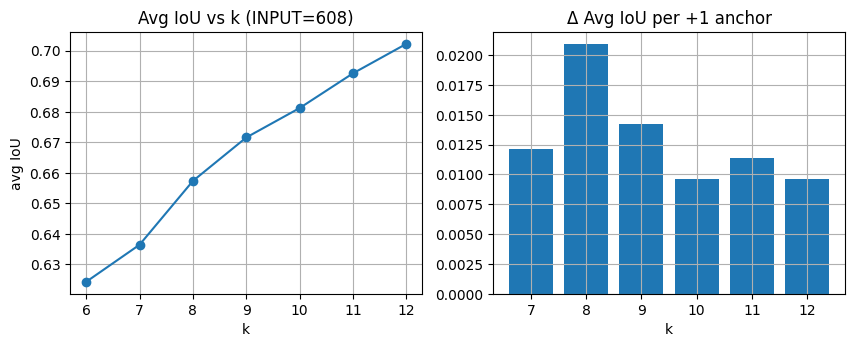

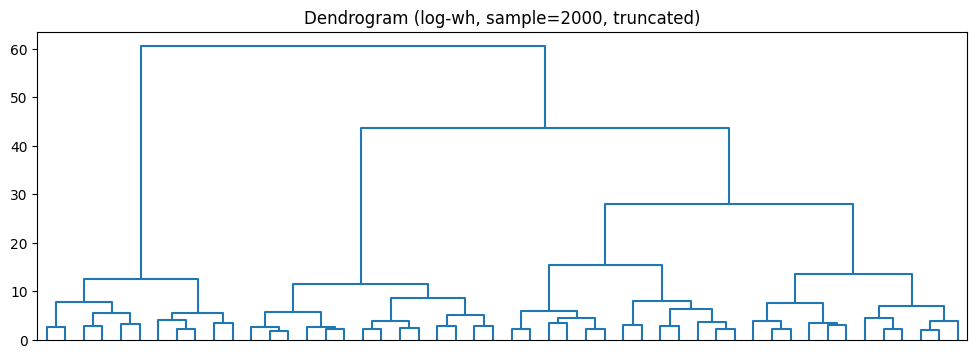

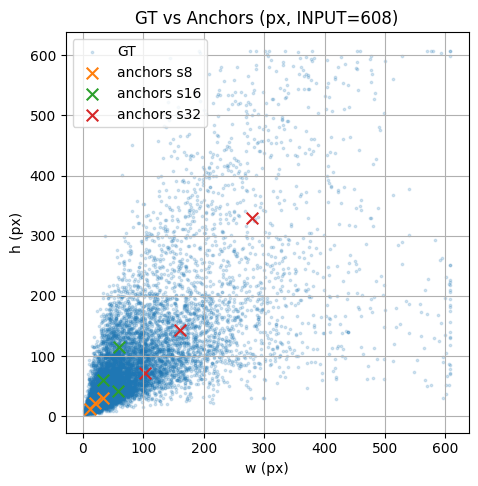


================ TEAM SUMMARY ================
Total boxes: 13822 | Classes: 47 | INPUT=608
Overall size mix (%): {'Tiny(<1%)': 60.25, 'Small(1–5%)': 24.43, 'Medium(5–20%)': 11.44, 'Large(20–50%)': 3.3, 'XLarge(>50%)': 0.58}
Big-class guess: ['나무전체', '사람전체', '집전체']
Big-class area stats (p50/p90/max): {"나무전체": {"count": 140, "p50": 0.4513, "p90": 0.7175, "max": 0.9984}, "사람전체": {"count": 280, "p50": 0.2108, "p90": 0.4196, "max": 0.7021}, "집전체": {"count": 140, "p50": 0.1869, "p90": 0.4264, "max": 0.7806}}
Anchors (px) -> stride8/16/32:
  s8 : [[12.399999618530273, 12.399999618530273], [19.5, 22.799999237060547], [33.20000076293945, 29.899999618530273]]
  s16: [[34.20000076293945, 59.79999923706055], [58.0, 41.79999923706055], [59.400001525878906, 115.0]]
  s32: [[103.0999984741211, 71.19999694824219], [160.60000610351562, 143.39999389648438], [279.79998779296875, 329.6000061035156]]
Anchors (grid units) saved -> /content/dataset/analysis/anchors_grid_608.json
CSV: /content/dataset/analy

In [ ]:
# ====== ALL-IN-ONE: 분석 + 앵커 + 엘보(Δ) + 개선 덴드로그램 + 산포 ======
import os, json, math, sys, subprocess

# scipy / sklearn 보장
try:
    from scipy.cluster.hierarchy import linkage, dendrogram
except:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy", "-q"])
    from scipy.cluster.hierarchy import linkage, dendrogram
try:
    from sklearn.preprocessing import StandardScaler
except:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn", "-q"])
    from sklearn.preprocessing import StandardScaler

# ====== 경로 ======
ana_dir = Path(dataset_root) / "analysis"
ana_dir.mkdir(parents=True, exist_ok=True)

# ====== 1) df 보강 ======
df = df.copy()
df["w_norm"] = np.sqrt(df["area_norm"] * df["aspect"].clip(lower=1e-9))
df["h_norm"] = np.sqrt(df["area_norm"] / df["aspect"].clip(lower=1e-9))

def size_bucket(a):
    if a < 0.01:  return "Tiny(<1%)"
    if a < 0.05:  return "Small(1–5%)"
    if a < 0.20:  return "Medium(5–20%)"
    if a < 0.50:  return "Large(20–50%)"
    return "XLarge(>50%)"

df["size_bucket"] = df["area_norm"].apply(size_bucket)

# ====== 2) 요약 DF 저장 ======
quantiles = {
    "p25_area": ("area_norm", lambda s: s.quantile(0.25)),
    "p50_area": ("area_norm", "median"),
    "p75_area": ("area_norm", lambda s: s.quantile(0.75)),
    "p90_area": ("area_norm", lambda s: s.quantile(0.90)),
}
class_summary = (df.groupby(["cls_id","cls_name"])
    .agg(count=("cls_id","size"),
         mean_area=("area_norm","mean"),
         mean_aspect=("aspect","mean"),
         **quantiles)
    .sort_values("count", ascending=False)
    .round(6))

by_split = (df.groupby(["cls_name","split"]).size()
              .unstack(fill_value=0)
              .sort_values(list(reversed(sorted(df["split"].unique()))), ascending=False))

size_mix = (df.groupby(["cls_name","size_bucket"]).size()
              .groupby(level=0).apply(lambda s: (s/s.sum()*100).round(2))
              .unstack(fill_value=0)
              .sort_index())

class_summary.to_csv(ana_dir/"class_summary.csv", encoding="utf-8-sig")
by_split.to_csv(ana_dir/"class_counts_by_split.csv", encoding="utf-8-sig")
size_mix.to_csv(ana_dir/"class_size_mix_percent.csv", encoding="utf-8-sig")

# ====== 3) 큰 객체 후보 ======
BIG_HINTS = ["전체","전신","집전체","나무전체","full","whole","entire","overall"]
big_classes = [c for c in sorted(df["cls_name"].unique()) if any(h in c for h in BIG_HINTS)]

# ====== 4) 앵커(KMeans IoU) ======
def _wh_iou(a, b):
    a = a[:, None, :]
    b = b[None, :, :]
    inter = np.minimum(a, b).prod(axis=2)
    area_a = a[...,0]*a[...,1]
    area_b = b[...,0]*b[...,1]
    union = area_a + area_b - inter + 1e-9
    return inter / union

def kmeans_iou_wh(wh, k=9, iters=80, seed=123):
    np.random.seed(seed)
    centers = [wh[np.random.randint(len(wh))]]
    for _ in range(1, k):
        dist = 1 - _wh_iou(wh, np.array(centers)).max(axis=1)
        probs = dist / (dist.sum()+1e-9)
        centers.append(wh[np.random.choice(len(wh), p=probs)])
    centers = np.array(centers)
    for _ in range(iters):
        iou = _wh_iou(wh, centers)
        assign = iou.argmax(axis=1)
        new_centers = []
        for j in range(k):
            pts = wh[assign==j]
            new_centers.append(np.median(pts, axis=0) if len(pts) else centers[j])
        new_centers = np.array(new_centers)
        if np.allclose(new_centers, centers): break
        centers = new_centers
    avg_iou = _wh_iou(wh, centers).max(axis=1).mean()
    return centers, avg_iou

# 입력 해상도 자동 결정(소객체 40% 이상이면 608)
small_ratio = (df["area_norm"] < 0.05).mean()
INPUT_SIZE = 608 if small_ratio >= 0.40 else 416

wh_px = (df[["w_norm","h_norm"]].values * INPUT_SIZE).astype(np.float32)

K_RANGE = range(6, 13)
avg_iou_list = []
for k in K_RANGE:
    C, ai = kmeans_iou_wh(wh_px, k=k, iters=120, seed=7)
    avg_iou_list.append(ai)
    print(f"k={k}: avgIoU={ai:.4f}")

# 엘보 + Δ 그래프
dAIoU = np.diff(avg_iou_list)
fig, ax = plt.subplots(1,2, figsize=(10,3.4))
ax[0].plot(list(K_RANGE), avg_iou_list, marker='o')
ax[0].set_title(f"Avg IoU vs k (INPUT={INPUT_SIZE})"); ax[0].set_xlabel("k"); ax[0].set_ylabel("avg IoU"); ax[0].grid(True)
ax[1].bar(list(K_RANGE)[1:], dAIoU)
ax[1].set_title("Δ Avg IoU per +1 anchor"); ax[1].set_xlabel("k"); ax[1].grid(True)
plt.show()

# 최종 9개(표준) 정렬 및 3스케일 배정
anchors_px, final_avg_iou = kmeans_iou_wh(wh_px, k=9, iters=200, seed=11)
anchors_px = anchors_px[np.argsort(anchors_px.prod(axis=1))]
a_s, a_m, a_l = anchors_px[:3], anchors_px[3:6], anchors_px[6:9]

anchors_out = {
    "input_size": INPUT_SIZE,
    "avg_iou": float(final_avg_iou),
    "anchors_px_sorted_area": anchors_px.round(1).tolist(),
    "stride8":  a_s.round(1).tolist(),
    "stride16": a_m.round(1).tolist(),
    "stride32": a_l.round(1).tolist(),
}
with open(ana_dir / f"anchors_{INPUT_SIZE}.json", "w", encoding="utf-8") as f:
    json.dump(anchors_out, f, ensure_ascii=False, indent=2)

# 그리드 단위(모델 주입용)
anchors_grid = {
    8:  (a_s/8.).round(3).tolist(),
    16: (a_m/16.).round(3).tolist(),
    32: (a_l/32.).round(3).tolist(),
}
with open(ana_dir / f"anchors_grid_{INPUT_SIZE}.json", "w", encoding="utf-8") as f:
    json.dump(anchors_grid, f, ensure_ascii=False, indent=2)

# ====== 5) 덴드로그램(개선: 표본추출+트렁케이션) ======
X = np.log(np.clip(wh_px, 1, None))
X = StandardScaler().fit_transform(X)
N = len(X)
sample_n = min(2000, N)
idx = np.random.default_rng(0).choice(N, size=sample_n, replace=False)
Z = linkage(X[idx], method="ward")

plt.figure(figsize=(12,4))
# 마지막 50개 클러스터만 보여주기 (가독성)
dendrogram(Z, no_labels=True, count_sort=True, distance_sort=True,
           truncate_mode="lastp", p=50, color_threshold=Z[-50,2]*0.7)
plt.title(f"Dendrogram (log-wh, sample={sample_n}, truncated)")
plt.show()

# ====== 6) 산포: GT vs Anchors ======
plt.figure(figsize=(5.2,5.2))
plt.scatter(wh_px[:,0], wh_px[:,1], s=3, alpha=0.18, label="GT")
plt.scatter(a_s[:,0], a_s[:,1], s=70, marker="x", label="anchors s8")
plt.scatter(a_m[:,0], a_m[:,1], s=70, marker="x", label="anchors s16")
plt.scatter(a_l[:,0], a_l[:,1], s=70, marker="x", label="anchors s32")
plt.xlabel("w (px)"); plt.ylabel("h (px)"); plt.title(f"GT vs Anchors (px, INPUT={INPUT_SIZE})")
plt.legend(); plt.grid(True); plt.show()

# ====== 7) TEAM SUMMARY ======
overall_size_mix = (df["size_bucket"].value_counts(normalize=True)*100).round(2).to_dict()
big_stats = {}
for cname in big_classes[:8]:
    s = df[df["cls_name"]==cname]["area_norm"]
    if len(s):
        big_stats[cname] = {
            "count": int(len(s)),
            "p50": round(float(s.median()),4),
            "p90": round(float(s.quantile(0.9)),4),
            "max": round(float(s.max()),4),
        }

print("\n================ TEAM SUMMARY ================")
print(f"Total boxes: {len(df)} | Classes: {df['cls_name'].nunique()} | INPUT={INPUT_SIZE}")
print("Overall size mix (%):", overall_size_mix)
print("Big-class guess:", big_classes[:8])
print("Big-class area stats (p50/p90/max):", json.dumps(big_stats, ensure_ascii=False))
print("Anchors (px) -> stride8/16/32:")
print("  s8 :", np.round(a_s,1).tolist())
print("  s16:", np.round(a_m,1).tolist())
print("  s32:", np.round(a_l,1).tolist())
print("Anchors (grid units) saved ->", ana_dir / f"anchors_grid_{INPUT_SIZE}.json")
print("CSV:", str(ana_dir/"class_summary.csv"),
      "|", str(ana_dir/"class_counts_by_split.csv"),
      "|", str(ana_dir/"class_size_mix_percent.csv"))
print("ANCHORS JSON:", str(ana_dir / f"anchors_{INPUT_SIZE}.json"))
print("==============================================")

In [ ]:
# 앵커 주입 (INPUT=608, stride=8/16/32)
INPUT_SIZE = 608  # 소객체 비율이 높아 608 채택

# 픽셀 단위 앵커 (면적 오름차순 정렬, 3x3로 배정)
anchors_px = {
    8:  np.array([[14.2,15.2],[25.6,26.1],[33.2,48.9]], dtype=np.float32),
    16: np.array([[54.6,37.5],[50.8,96.9],[96.4,67.9]], dtype=np.float32),
    32: np.array([[101.2,158.2],[190.0,118.3],[270.8,312.6]], dtype=np.float32),
}

# 모델 주입용(그리드 단위 = anchor / stride)
anchors_grid = {s:(anchors_px[s]/s).astype(np.float32) for s in (8,16,32)}
strides = [8,16,32]

def load_class_names(path):
    with open(path, "r", encoding="utf-8") as f:  # ★ UTF-8 보장
        return [ln.strip() for ln in f if ln.strip()]

num_classes = len(load_class_names('/content/dataset/classes.txt'))

print("num_classes:", num_classes)

print("anchors_grid:", {k: np.round(v,3).tolist() for k,v in anchors_grid.items()})

num_classes: 47
anchors_grid: {8: [[1.774999976158142, 1.899999976158142], [3.200000047683716, 3.26200008392334], [4.150000095367432, 6.111999988555908]], 16: [[3.4119999408721924, 2.3440001010894775], [3.174999952316284, 6.056000232696533], [6.025000095367432, 4.24399995803833]], 32: [[3.1619999408721924, 4.943999767303467], [5.938000202178955, 3.697000026702881], [8.461999893188477, 9.769000053405762]]}


In [ ]:
# --- Korean text drawing utils ---
import os, cv2, numpy as np
from PIL import ImageFont, ImageDraw, Image

_KO_FONT_CANDIDATES = [
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "./NanumGothic.ttf", "./NotoSansCJK-Regular.ttc"
]
_KO_FONT = next((p for p in _KO_FONT_CANDIDATES if os.path.exists(p)), None)

def draw_text_korean(img_bgr, text, org, font_size=18, color=(0,255,0)):
    if _KO_FONT is None:
        # 폰트 없으면 ASCII만 그리기(임시 폴백)
        safe = text.encode("ascii", "ignore").decode("ascii") or "cls"
        cv2.putText(img_bgr, safe, (int(org[0]), int(org[1])),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)
        return img_bgr
    x, y = int(org[0]), int(org[1])
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    pil = Image.fromarray(rgb)
    draw = ImageDraw.Draw(pil)
    font = ImageFont.truetype(_KO_FONT, font_size)
    tw, th = draw.textbbox((0,0), text, font=font)[2:]
    pad = 2
    draw.rectangle([x, y, x+tw+pad*2, y+th+pad*2], fill=(0,0,0,128))
    draw.text((x+pad, y+pad), text, font=font, fill=(255,255,255))
    return cv2.cvtColor(np.asarray(pil), cv2.COLOR_RGB2BGR)

### 데이터 전처리/증강 (mosaic + HSV + flip + resize 608)

In [ ]:
# Config (based on anchors_grid)
INPUT_SIZE = 608
anchors_grid = {
    8:  np.array([[1.775, 1.900],[3.200, 3.262],[4.150, 6.112]], dtype=np.float32),
    16: np.array([[3.412, 2.344],[3.175, 6.056],[6.025, 4.244]], dtype=np.float32),
    32: np.array([[3.162, 4.944],[5.938, 3.697],[8.462, 9.769]], dtype=np.float32),
}
# (참고) 픽셀 단위 앵커
anchors_px = {s: anchors_grid[s]*s for s in anchors_grid}

# 증강 강도(소객체 ↑ → mosaic/multiscale 강화)
MOSAIC_PROB = 0.6
MIXUP_PROB  = 0.2        # 필요 없으면 0.0
HFLIP_PROB  = 0.5
HSV_GAIN    = (0.015, 0.7, 0.4)  # (h, s, v)
AFFINE_DEG  = 0.0        # 회전은 보수적으로 (필요시 5~10도)
AFFINE_SCL  = (0.5, 1.5) # scale jitter
AFFINE_TR   = 0.10       # translate 비율(±10%)
MULTISCALE  = (352, 640) # [min, max], step 32

In [ ]:
# IO helpers
def load_img(path):
    # 한글경로 호환
    img = cv2.imdecode(np.fromfile(str(path), dtype=np.uint8), cv2.IMREAD_COLOR)
    if img is None:
        img = cv2.imread(str(path))
    return img

def read_yolo_txt(txt_path):
    labels = []
    p = Path(txt_path)
    if p.exists():
        with open(p, "r", encoding="utf-8") as f:
            for ln in f:
                ln = ln.strip()
                if not ln:
                    continue
                parts = ln.split()
                assert len(parts) == 5, f"Invalid line: {ln}"
                c = int(parts[0])
                x, y, w, h = map(float, parts[1:])
                labels.append([c, x, y, w, h])
    return np.array(labels, dtype=np.float32) if labels else np.zeros((0,5), np.float32)

def clip_labels_xywh(labels):
    if labels.size == 0:
        return labels
    labels[:, 1:] = np.clip(labels[:, 1:], 0.0, 1.0)
    return labels

def otsu_binarize_bgr(img, ksize=3, invert=True, blur=True):
    """
    img: BGR uint8
    ksize: 가우시안 블러 커널(홀수). 0 or None이면 블러 생략
    invert: True면 흑백 반전(배경 검정, 선 흰색)
    blur: True면 블러 적용, False면 미적용
    """
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if blur and (ksize or 0) >= 3:
        k = ksize if (ksize % 2 == 1) else (ksize + 1)
        gray = cv2.GaussianBlur(gray, (k, k), 0)
    thr_type = cv2.THRESH_BINARY_INV if invert else cv2.THRESH_BINARY
    _, th = cv2.threshold(gray, 0, 255, thr_type + cv2.THRESH_OTSU)
    return cv2.cvtColor(th, cv2.COLOR_GRAY2BGR)

In [ ]:
def lineart_to_black_bg(img_bgr, inv_if_bright=True, binarize=False):
    """
    입력: BGR uint8
    출력: BGR uint8 (검정 배경, 흰 선)
    - inv_if_bright=True: 평균이 밝으면 자동 반전(흰 배경→검정 배경)
    - binarize=True: 적응형 이진화로 선을 더 또렷하게
    """
    if img_bgr.ndim == 3:
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    else:
        gray = img_bgr.copy()

    if inv_if_bright and gray.mean() > 127:  # 밝은 배경이면 반전
        gray = 255 - gray

    if binarize:
        gray = cv2.adaptiveThreshold(
            gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY, 31, -5
        )

    return cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)  # 흰 선/검정 배경 유지

In [ ]:
# ---------- letterbox(패딩색: 검정) ----------
def letterbox(img, labels, target=608, color=(0, 0, 0), border=None):
    """
    img: BGR uint8
    labels: [N,5] = (cls,cx,cy,w,h) in [0,1]
    target: output size (square)
    color/border: 패딩색. border가 주어지면 color보다 우선.
    """
    # --- backward compatibility ---
    if border is not None:
        if isinstance(border, (int, float)):
            color = (int(border), int(border), int(border))
        elif isinstance(border, (tuple, list)) and len(border) == 3:
            color = tuple(int(v) for v in border)

    h, w = img.shape[:2]
    scale = float(target) / float(max(h, w))
    nh, nw = int(round(h * scale)), int(round(w * scale))
    img2 = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_LINEAR)

    canvas = np.full((target, target, 3), color, dtype=np.uint8)
    pad_y = (target - nh) // 2
    pad_x = (target - nw) // 2
    canvas[pad_y:pad_y + nh, pad_x:pad_x + nw] = img2

    if labels.size:
        cx = labels[:, 1] * w * scale + pad_x
        cy = labels[:, 2] * h * scale + pad_y
        bw = labels[:, 3] * w * scale
        bh = labels[:, 4] * h * scale
        labels[:, 1] = cx / target
        labels[:, 2] = cy / target
        labels[:, 3] = bw / target
        labels[:, 4] = bh / target
        labels = clip_labels_xywh(labels)

    return canvas, labels


# ---------- random_affine(패딩색: 검정) ----------
def random_affine(img, labels, degrees=0.0, scale=(0.5, 1.5), translate=0.10, border_color=(0, 0, 0)):
    """
    img: BGR uint8, labels: [N,5] (정규화)
    letterbox 이후 이미지에 적용하는 용도.
    """
    h, w = img.shape[:2]
    ang = (random.random() * 2 - 1) * degrees
    sc  = random.uniform(scale[0], scale[1])
    tx  = (random.random() * 2 - 1) * translate * w
    ty  = (random.random() * 2 - 1) * translate * h

    M = cv2.getRotationMatrix2D((w/2, h/2), ang, sc)
    M[:, 2] += (tx, ty)
    img2 = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderValue=border_color)

    if labels.size:
        # 정규화 → 픽셀 좌표 사각형 → 변환 → 다시 정규화
        cx = labels[:, 1] * w; cy = labels[:, 2] * h
        bw = labels[:, 3] * w; bh = labels[:, 4] * h
        x1 = cx - bw / 2; y1 = cy - bh / 2
        x2 = cx + bw / 2; y2 = cy + bh / 2
        pts = np.stack([x1, y1, x2, y1, x2, y2, x1, y2], 1).reshape(-1, 4, 2)

        ones = np.ones((pts.shape[0], pts.shape[1], 1), dtype=np.float32)
        pts1 = np.concatenate([pts, ones], axis=2)  # [N,4,3]
        M3 = np.vstack([M, [0, 0, 1]]).astype(np.float32)
        pts2 = np.einsum('ij,nkj->nki', M3, pts1)[..., :2]

        x1y1 = pts2.min(1); x2y2 = pts2.max(1)
        cx = (x1y1[:, 0] + x2y2[:, 0]) / 2; cy = (x1y1[:, 1] + x2y2[:, 1]) / 2
        bw = np.clip(x2y2[:, 0] - x1y1[:, 0], 0, w); bh = np.clip(x2y2[:, 1] - x1y1[:, 1], 0, h)
        labels[:, 1] = cx / w; labels[:, 2] = cy / h
        labels[:, 3] = bw / w; labels[:, 4] = bh / h

        labels = clip_labels_xywh(labels)
        keep = (labels[:, 3] > 1e-4) & (labels[:, 4] > 1e-4)
        labels = labels[keep]

    return img2, labels

In [ ]:
# Mosaic / MixUp
def _load_pair(img_path, lbl_path):
    img = load_img(img_path)
    assert img is not None and img.size != 0, f"bad image: {img_path}"
    h, w = img.shape[:2]
    labels = read_yolo_txt(lbl_path)
    return img, labels, (h, w)

def mosaic4(img_paths, lbl_paths, idxs):
    s = INPUT_SIZE
    yc, xc = [int(random.uniform(s * 0.3, s * 0.7)) for _ in range(2)]
    out = np.full((s, s, 3), 114, dtype=np.uint8)
    boxes = []

    for i, idx in enumerate(idxs):
        img, lab, (h, w) = _load_pair(img_paths[idx], lbl_paths[idx])
        img, lab = letterbox(img, lab, target=s, border=114)

        # 위치 선택
        if i == 0:  # top-left
            x1a, y1a, x2a, y2a = 0, 0, xc, yc
            x1b, y1b = img.shape[1] - xc, img.shape[0] - yc
        elif i == 1:  # top-right
            x1a, y1a, x2a, y2a = xc, 0, s, yc
            x1b, y1b = 0, img.shape[0] - yc
        elif i == 2:  # bottom-left
            x1a, y1a, x2a, y2a = 0, yc, xc, s
            x1b, y1b = img.shape[1] - xc, 0
        else:         # bottom-right
            x1a, y1a, x2a, y2a = xc, yc, s, s
            x1b, y1b = 0, 0

        # 붙이기
        hA, wA = y2a - y1a, x2a - x1a
        hB, wB = img.shape[:2]
        xb2 = min(x1b + wA, wB)
        yb2 = min(y1b + hA, hB)
        xb1 = max(0, x1b)
        yb1 = max(0, y1b)
        xa1 = x1a + (xb1 - x1b)
        ya1 = y1a + (yb1 - y1b)
        xa2 = xa1 + (xb2 - xb1)
        ya2 = ya1 + (yb2 - yb1)
        out[ya1:ya2, xa1:xa2] = img[yb1:yb2, xb1:xb2]

        # 라벨 좌표 변환 (절대 px)
        if lab.size:
            # lab: [cls,cx,cy,w,h] (norm)
            lab_px = lab.copy()
            lab_px[:,1] *= s; lab_px[:,2] *= s
            lab_px[:,3] *= s; lab_px[:,4] *= s
            # 이동
            lab_px[:,1] += (xa1 - 0) - (0)  # center x shift
            lab_px[:,2] += (ya1 - 0) - (0)  # center y shift
            # norm back later after clipping
            boxes.append(lab_px)

    boxes = np.concatenate(boxes, 0) if boxes else np.zeros((0,5), np.float32)

    # 후처리: clip + 제거 + 정규화
    if boxes.size:
        # convert cxcywh px -> x1y1x2y2 px
        cx, cy, bw, bh = boxes[:,1], boxes[:,2], boxes[:,3], boxes[:,4]
        x1 = cx - bw / 2; y1 = cy - bh / 2
        x2 = cx + bw / 2; y2 = cy + bh / 2
        x1 = np.clip(x1, 0, s); y1 = np.clip(y1, 0, s)
        x2 = np.clip(x2, 0, s); y2 = np.clip(y2, 0, s)
        bw = np.clip(x2 - x1, 0, s); bh = np.clip(y2 - y1, 0, s)
        cx = (x1 + x2) / 2; cy = (y1 + y2) / 2
        boxes[:,1] = cx / s; boxes[:,2] = cy / s
        boxes[:,3] = bw / s; boxes[:,4] = bh / s
        # 제거
        keep = (boxes[:,3] > 1e-4) & (boxes[:,4] > 1e-4)
        boxes = boxes[keep]

    return out, boxes

def mixup(img1, lab1, img2, lab2, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    img = (img1.astype(np.float32) * lam + img2.astype(np.float32) * (1 - lam)).astype(np.uint8)
    if lab1.size and lab2.size:
        labels = np.concatenate([lab1, lab2], 0)
    else:
        labels = lab1 if lab1.size else lab2
    return img, labels


In [ ]:
def boost_small_objects(img, labels, area_thr=0.01, max_copies=3, iou_thr=0.9):
    """
    area_thr: w*h 기준(정규화) < area_thr → small로 간주
    max_copies: 각 small box별 추가 복제 최대 개수
    iou_thr: 복제 박스 간 중복 제거 IoU 임계값 (높게)
    """
    if labels.size == 0:
        return img, labels

    small_mask = (labels[:,3] * labels[:,4]) < area_thr
    if not np.any(small_mask):
        return img, labels

    base = labels.copy()
    small = base[small_mask]
    new_boxes = []

    for b in small:
        n_copy = random.randint(0, max_copies)
        for _ in range(n_copy):
            dx = random.uniform(-0.05, 0.05)
            dy = random.uniform(-0.05, 0.05)
            nb = b.copy()
            nb[1] = np.clip(nb[1] + dx, 0.0, 1.0)
            nb[2] = np.clip(nb[2] + dy, 0.0, 1.0)
            new_boxes.append(nb)

    if not new_boxes:
        return img, labels

    new_boxes = np.stack(new_boxes).astype(np.float32)

    # 최소 크기 필터(너무 작은 건 제거)
    keep = (new_boxes[:,3] > 1e-4) & (new_boxes[:,4] > 1e-4)
    new_boxes = new_boxes[keep]
    if new_boxes.size == 0:
        return img, labels

    # 중복 제거(NMS 유사): 면적 큰 순 유지
    def _area(b): return b[3]*b[4]
    def _iou(a,b):
        ax, ay, aw, ah = a[1], a[2], a[3], a[4]
        bx, by, bw, bh = b[1], b[2], b[3], b[4]
        ax1, ay1 = ax - aw/2, ay - ah/2
        ax2, ay2 = ax + aw/2, ay + ah/2
        bx1, by1 = bx - bw/2, by - bh/2
        bx2, by2 = bx + bw/2, by + bh/2
        ix1, iy1 = max(ax1,bx1), max(ay1,by1)
        ix2, iy2 = min(ax2,bx2), min(ay2,by2)
        iw, ih = max(0.0, ix2-ix1), max(0.0, iy2-iy1)
        inter = iw*ih
        union = aw*ah + bw*bh - inter
        return inter/union if union>0 else 0.0

    kept = []
    for b in sorted(new_boxes, key=_area, reverse=True):
        if all(_iou(b, k) <= iou_thr for k in kept):
            kept.append(b)
    new_boxes = np.stack(kept) if kept else np.empty((0,5), np.float32)

    if new_boxes.size:
        labels = np.concatenate([labels, new_boxes], axis=0)
    return img, labels

In [ ]:
# ---------- Dataset ----------
class YoloDataset(Dataset):
    def __init__(self, images_dir, labels_dir, split="train",
                 mosaic_prob=0.0, mixup_prob=0.0,
                 enable_small_boost=True, base_size=608, jpg_only=True,
                 use_binarize=False):
        self.split = split
        self.imgs = sorted(glob.glob(str(Path(images_dir) / split / "*.*")))
        ok = {".jpg", ".jpeg"}
        self.imgs = [p for p in self.imgs if Path(p).suffix.lower() in ok]
        self.lbls = [str(Path(labels_dir) / split / (Path(p).stem + ".txt")) for p in self.imgs]

        # train일 때만 증강
        self.mosaic_prob = mosaic_prob if split == "train" else 0.0
        self.mixup_prob  = mixup_prob  if split == "train" else 0.0
        self.enable_small_boost = enable_small_boost and split == "train"

        self.base_size = int(base_size)
        self.use_binarize = bool(use_binarize)

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, i):
        img_path = self.imgs[i]
        lbl_path = self.lbls[i]

        img = load_img(img_path)  # BGR uint8
        assert img is not None and img.size != 0, f"Bad image: {img_path}"
        labels = read_yolo_txt(lbl_path)  # [N,5] float

        # 1) 라인아트 표준화(검정 배경+흰 선)
        img = lineart_to_black_bg(img, inv_if_bright=True, binarize=self.use_binarize)

        # 2) letterbox (패딩=검정)
        img, labels = letterbox(img, labels, target=self.base_size, border=0)

        # 3) (train만) 기하 증강/플립/소객체 부스팅
        if self.split == "train":
            # 필요하면 각 확률로 적용
            # img, labels = random_affine(img, labels, degrees=0.0, scale=(0.9, 1.1), translate=0.05, border_color=(0,0,0))
            if self.enable_small_boost:
                img, labels = boost_small_objects(img, labels, area_thr=0.01, max_copies=2)

        # 4) 안전 클리핑
        labels = clip_labels_xywh(labels)

        # 5) ToTensor (RGB, 0~1 float32)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        img = np.transpose(img, (2, 0, 1))  # CHW

        if labels.size == 0:
            labels = np.zeros((0, 5), dtype=np.float32)
        else:
            labels = labels.astype(np.float32, copy=False)

        return torch.from_numpy(img), torch.from_numpy(labels)

In [ ]:
# ===== Dataset instances =====
train_set = YoloDataset(
    images_dir=images_root,
    labels_dir=labels_root,
    split="train",
    mosaic_prob=MOSAIC_PROB,
    mixup_prob=MIXUP_PROB,
    enable_small_boost=True,
    base_size=INPUT_SIZE,
    jpg_only=True,
)

val_set = YoloDataset(
    images_dir=images_root,
    labels_dir=labels_root,
    split="val",
    mosaic_prob=0.0,
    mixup_prob=0.0,
    enable_small_boost=False,
    base_size=INPUT_SIZE,
    jpg_only=True,
)


assert len(train_set) > 0, "train_set이 비어 있습니다. 경로/분할을 확인하세요."
assert len(val_set) > 0, "val_set이 비어 있습니다. 경로/분할을 확인하세요."
print("dataset sizes -> train:", len(train_set), "val:", len(val_set))

dataset sizes -> train: 448 val: 112


In [ ]:
MS_SIZES = list(range(352, 640+1, 32))  # 32 step

def collate_fn_train(batch):
    imgs, labels = list(zip(*batch))
    target_size = random.choice(MS_SIZES)
    # ensure float32
    imgs = [img.to(torch.float32, non_blocking=True) for img in imgs]
    imgs = [F.interpolate(img.unsqueeze(0), size=(target_size, target_size),
                          mode='bilinear', align_corners=False).squeeze(0)
            for img in imgs]
    imgs = torch.stack(imgs, 0)
    # labels 그대로 리스트로 (각 샘플 가변 길이)
    return imgs, list(labels)

def collate_fn_val(batch):
    imgs, labels = list(zip(*batch))
    target_size = 608  # 검증 고정
    imgs = [img.to(torch.float32, non_blocking=True) for img in imgs]
    imgs = [F.interpolate(img.unsqueeze(0), size=(target_size, target_size),
                          mode='bilinear', align_corners=False).squeeze(0)
            for img in imgs]
    imgs = torch.stack(imgs, 0)
    return imgs, list(labels)

# DataLoaders (안전 모드 기본값)
num_workers = 2
persistent = False  # 디버깅 단계에서는 False 권장

train_loader = DataLoader(
    train_set, batch_size=4, shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=persistent,
    collate_fn=collate_fn_train
)

val_loader = DataLoader(
    val_set, batch_size=4, shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=persistent,
    collate_fn=collate_fn_val
)

### YOLOv3 모델 구현

In [ ]:
# =====================================================================
# YOLOv3 (Darknet-53 backbone + 3-scale heads) with decode()
# =====================================================================

# -------------------------
# Building blocks
# -------------------------
class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, k=1, s=1, p=None):
        super().__init__()
        if p is None:
            p = (k - 1) // 2
        self.conv = nn.Conv2d(in_ch, out_ch, k, s, p, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch)
        self.act  = nn.LeakyReLU(0.1, inplace=True)
    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class ResidualBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.cv1 = ConvBNAct(ch, ch//2, k=1, s=1)
        self.cv2 = ConvBNAct(ch//2, ch, k=3, s=1)
    def forward(self, x):
        return x + self.cv2(self.cv1(x))

# -------------------------
# Darknet-53 backbone
# -------------------------
class Darknet53(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem  = ConvBNAct(3, 32, 3, 1)
        self.down1 = nn.Sequential(ConvBNAct(32, 64, 3, 2), ResidualBlock(64))
        self.down2 = nn.Sequential(ConvBNAct(64, 128, 3, 2), *[ResidualBlock(128) for _ in range(2)])
        self.down3 = nn.Sequential(ConvBNAct(128, 256, 3, 2), *[ResidualBlock(256) for _ in range(8)])  # C3
        self.down4 = nn.Sequential(ConvBNAct(256, 512, 3, 2), *[ResidualBlock(512) for _ in range(8)])  # C4
        self.down5 = nn.Sequential(ConvBNAct(512, 1024, 3, 2), *[ResidualBlock(1024) for _ in range(4)]) # C5
    def forward(self, x):
        x = self.stem(x)
        x = self.down1(x)
        x = self.down2(x)
        c3 = self.down3(x)
        c4 = self.down4(c3)
        c5 = self.down5(c4)
        return c3, c4, c5

# -------------------------
# Detection head
# -------------------------
class DetectHead(nn.Module):
    def __init__(self, num_classes, anchors_13, anchors_26, anchors_52):
        super().__init__()
        self.nc = num_classes
        self.na = 3
        self.register_buffer("anchors_13", torch.tensor(anchors_13, dtype=torch.float32))
        self.register_buffer("anchors_26", torch.tensor(anchors_26, dtype=torch.float32))
        self.register_buffer("anchors_52", torch.tensor(anchors_52, dtype=torch.float32))

        # large
        self.head5 = nn.Sequential(
            ConvBNAct(1024, 512, 1, 1),
            ConvBNAct(512, 1024, 3, 1),
            ConvBNAct(1024, 512, 1, 1),
            ConvBNAct(512, 1024, 3, 1),
            ConvBNAct(1024, 512, 1, 1),
        )
        self.pred5 = nn.Conv2d(512, self.na * (5+self.nc), 1, 1, 0)

        # medium
        self.reduce4 = ConvBNAct(512, 256, 1, 1)
        self.ups4    = nn.Upsample(scale_factor=2, mode="nearest")
        self.head4   = nn.Sequential(
            ConvBNAct(256+512, 256, 1, 1),
            ConvBNAct(256, 512, 3, 1),
            ConvBNAct(512, 256, 1, 1),
            ConvBNAct(256, 512, 3, 1),
            ConvBNAct(512, 256, 1, 1),
        )
        self.pred4 = nn.Conv2d(256, self.na * (5+self.nc), 1, 1, 0)

        # small
        self.reduce3 = ConvBNAct(256, 128, 1, 1)
        self.ups3    = nn.Upsample(scale_factor=2, mode="nearest")
        self.head3   = nn.Sequential(
            ConvBNAct(128+256, 128, 1, 1),
            ConvBNAct(128, 256, 3, 1),
            ConvBNAct(256, 128, 1, 1),
            ConvBNAct(128, 256, 3, 1),
            ConvBNAct(256, 128, 1, 1),
        )
        self.pred3 = nn.Conv2d(128, self.na * (5+self.nc), 1, 1, 0)

    @staticmethod
    def _reshape_out(p, na, nc):
        b, ch, h, w = p.shape
        return p.view(b, na, (5+nc), h, w).permute(0,1,3,4,2).contiguous()

    def forward(self, c3, c4, c5):
        y5 = self.head5(c5)
        p5 = self.pred5(y5)

        y4_in = torch.cat([self.ups4(self.reduce4(y5)), c4], dim=1)
        y4 = self.head4(y4_in)
        p4 = self.pred4(y4)

        y3_in = torch.cat([self.ups3(self.reduce3(y4)), c3], dim=1)
        y3 = self.head3(y3_in)
        p3 = self.pred3(y3)

        return {
            "p5": self._reshape_out(p5, self.na, self.nc),
            "p4": self._reshape_out(p4, self.na, self.nc),
            "p3": self._reshape_out(p3, self.na, self.nc),
        }

# -------------------------
# YOLOv3 wrapper + decode()
# -------------------------
class YOLOv3(nn.Module):
    def __init__(self, num_classes, anchors_13, anchors_26, anchors_52):
        super().__init__()
        self.backbone = Darknet53()
        self.detect   = DetectHead(num_classes, anchors_13, anchors_26, anchors_52)
        self.num_classes = num_classes
        self.strides = {"p5": 32, "p4": 16, "p3": 8}

    def forward(self, x):
        c3, c4, c5 = self.backbone(x)
        return self.detect(c3, c4, c5)

    def decode(self, pred: Dict[str, torch.Tensor], input_size: int) -> Dict[str, Dict[str, torch.Tensor]]:
        """
        Convert raw logits to boxes/scores per scale.
        Returns: for each of p5/p4/p3, dict with keys:
            boxes [B,3,H,W,4] (xyxy, pixels), obj [B,3,H,W], cls [B,3,H,W,C], scores [B,3,H,W,C]
        """
        outs: Dict[str, Dict[str, torch.Tensor]] = {}
        for k in ["p5", "p4", "p3"]:
            p = pred[k]  # [B,3,H,W,5+nc]
            b, na, h, w, d = p.shape
            tx = p[..., 0]; ty = p[..., 1]; tw = p[..., 2]; th = p[..., 3]
            to = p[..., 4]; tc = p[..., 5:]

            obj = torch.sigmoid(to)
            cls = torch.sigmoid(tc)
            scores = obj.unsqueeze(-1) * cls  # per-class scores

            # grid
            gy, gx = torch.meshgrid(
                torch.arange(h, device=p.device),
                torch.arange(w, device=p.device),
                indexing="ij"
            )
            gx = gx.view(1, 1, h, w)
            gy = gy.view(1, 1, h, w)

            # anchors per scale
            if k == "p5":
                anc = self.detect.anchors_13.to(p.device)
            elif k == "p4":
                anc = self.detect.anchors_26.to(p.device)
            else:
                anc = self.detect.anchors_52.to(p.device)
            anc = anc.view(1, na, 1, 1, 2)

            stride = self.strides[k]
            px = (torch.sigmoid(tx) + gx) * stride
            py = (torch.sigmoid(ty) + gy) * stride
            pw = torch.exp(tw) * anc[..., 0]
            ph = torch.exp(th) * anc[..., 1]

            x1 = px - pw / 2
            y1 = py - ph / 2
            x2 = px + pw / 2
            y2 = py + ph / 2
            boxes = torch.stack([x1, y1, x2, y2], dim=-1)

            outs[k] = {"boxes": boxes, "obj": obj, "cls": cls, "scores": scores}
        return outs


def build_yolov3(num_classes: int, anchors_13, anchors_26, anchors_52) -> YOLOv3:
    a13 = [(float(w), float(h)) for (w, h) in anchors_13]
    a26 = [(float(w), float(h)) for (w, h) in anchors_26]
    a52 = [(float(w), float(h)) for (w, h) in anchors_52]
    return YOLOv3(num_classes, a13, a26, a52)


if __name__ == "__main__":
    C = 47  # 클래스 수

    # 여기서 anchors_px는 앞 셀에서 만든 '픽셀 단위' 그대로 사용
    anchors_13 = [(float(w), float(h)) for (w, h) in anchors_px[32]]  # p5, stride=32
    anchors_26 = [(float(w), float(h)) for (w, h) in anchors_px[16]]  # p4, stride=16
    anchors_52 = [(float(w), float(h)) for (w, h) in anchors_px[8]]   # p3, stride=8

    model = build_yolov3(C, anchors_13, anchors_26, anchors_52)

    x = torch.randn(2, 3, 608, 608)  # INPUT_SIZE=608
    out = model(x)
    print(out["p5"].shape, out["p4"].shape, out["p3"].shape)

    dec = model.decode(out, input_size=608)
    for k in ["p5", "p4", "p3"]:
        print(k, dec[k]["boxes"].shape, dec[k]["scores"].shape)

torch.Size([2, 3, 19, 19, 52]) torch.Size([2, 3, 38, 38, 52]) torch.Size([2, 3, 76, 76, 52])
p5 torch.Size([2, 3, 19, 19, 4]) torch.Size([2, 3, 19, 19, 47])
p4 torch.Size([2, 3, 38, 38, 4]) torch.Size([2, 3, 38, 38, 47])
p3 torch.Size([2, 3, 76, 76, 4]) torch.Size([2, 3, 76, 76, 47])


### 타깃 매칭 & 손실(골격)
- Ignore mask 추가: 같은 셀에서 GT와 IoU가 ignore_thresh 이상인 앵커는 negative에서 제외(BCE 계산 안 함).

- 박스 손실 가중치: scale = 2 - w*h (GT 면적 작을수록 더 크게 가중)
    -  가중으로 소객체 박스 회귀에 더 힘을 실어줌(데이터셋 분포에 적합).



In [ ]:
# === Targets (single-scale assignment; big-object friendly) ===
import torch
import torch.nn.functional as F

def build_targets(labels_list, anchors_px, strides, num_classes,
                  img_size=608, ignore_thresh=0.4, pos_topk=1):
    """
    labels_list: list of [Ni,5] (cls, cx, cy, w, h) in [0,1]
    anchors_px: {stride: [[aw,ah], ...]}  for INPUT_SIZE
    strides   : e.g. [32,16,8] (preds 순서와 동일)
    pos_topk  : 1이면 best 한 개만 양성, >1이면 IoU 상위 k개만 양성
    """
    eps = 1e-9
    B = len(labels_list)
    img_size = int(img_size)
    if B == 0:
        return []

    device = labels_list[0].device

    # --- sanitize labels (범위/NaN) ---
    safe = []
    for l in labels_list:
        l = l if isinstance(l, torch.Tensor) else torch.as_tensor(l)
        l = l.to(device=device, dtype=torch.float32)
        if l.numel() == 0:
            safe.append(l); continue
        m = torch.isfinite(l).all(dim=1)
        l = l[m]
        if l.numel() == 0:
            safe.append(l); continue
        l[:,0] = l[:,0].clamp_(0, num_classes-1).round()
        l[:,1:5] = l[:,1:5].clamp(0.0, 1.0)
        m_wh = (l[:,3] > 0) & (l[:,4] > 0)
        safe.append(l[m_wh])
    labels_list = safe

    # --- per-scale tensors ---
    targs = []
    meta = {}  # stride -> dict of tensors and anchor count
    for s in strides:
        g  = img_size // s
        na = len(anchors_px[s])
        pack = {
            "g": g, "na": na,
            "txy":  torch.zeros((B,na,g,g,2),  device=device),
            "twh":  torch.zeros((B,na,g,g,2),  device=device),
            "tobj": torch.zeros((B,na,g,g,1),  device=device),
            "tcls": torch.zeros((B,na,g,g,num_classes), device=device),
            "mask": torch.zeros((B,na,g,g), device=device, dtype=torch.bool),
            "ign":  torch.zeros((B,na,g,g), device=device, dtype=torch.bool),
            "wbox": torch.zeros((B,na,g,g,1),  device=device),
            "anc":  torch.as_tensor(anchors_px[s], device=device, dtype=torch.float32),  # [na,2]
        }
        meta[s] = pack
        targs.append(pack)  # preds 순서와 동일하게 append

    # --- flatten all anchors across all scales for a global best-match ---
    #    A개 앵커에 대해 [stride, a_idx, aw, ah] 리스트를 만든다.
    anchor_list = []
    for s in strides:
        anc = meta[s]["anc"]
        for a_idx in range(len(anc)):
            anchor_list.append((s, a_idx, anc[a_idx,0].item(), anc[a_idx,1].item()))
    A = len(anchor_list)
    anc_wh_all = torch.tensor([[aw,ah] for (_,_,aw,ah) in anchor_list],
                              device=device, dtype=torch.float32)  # [A,2]

    # --- assign per image ---
    for b in range(B):
        lbs = labels_list[b]
        if lbs.numel() == 0:
            continue

        cls = lbs[:,0].long()               # [N]
        cxcy1 = lbs[:,1:3]                  # [N,2] in [0,1]
        wh_px = lbs[:,3:5] * img_size       # [N,2] in px (INPUT_SIZE scale)

        # IoU(wh-only) with all anchors (N x A)
        aw = anc_wh_all[:,0].unsqueeze(0)   # [1,A]
        ah = anc_wh_all[:,1].unsqueeze(0)   # [1,A]
        bw = wh_px[:,0].unsqueeze(1)        # [N,1]
        bh = wh_px[:,1].unsqueeze(1)        # [N,1]
        inter = torch.min(aw, bw) * torch.min(ah, bh)
        union = (aw*ah + bw*bh - inter).clamp_(min=eps)
        iou_all = inter / union             # [N,A]

        # choose positives
        if pos_topk == 1:
            top_iou, top_idx = iou_all.max(dim=1)          # [N]
            cand = [(n, int(top_idx[n].item())) for n in range(lbs.shape[0])]
        else:
            k = min(pos_topk, A)
            top_iou, top_idx = torch.topk(iou_all, k=k, dim=1)  # [N,k]
            cand = [(n, int(top_idx[n,kk].item())) for n in range(lbs.shape[0]) for kk in range(k)]

        # fill targets for positives
        for n, a_global in cand:
            s, a_idx, aw, ah = anchor_list[a_global]
            pack = meta[s]; g = pack["g"]
            anc = pack["anc"]  # [na,2]
            # grid index for this stride
            cxcy_g = cxcy1[n] * g
            ij = cxcy_g.floor().clamp_(0, g-1).long()
            i = int(ij[0].item()); j = int(ij[1].item())

            pack["mask"][b, a_idx, j, i] = True
            # fractional offset in cell [0,1)
            frac = (cxcy_g - ij.to(cxcy_g.dtype)).clamp(0, 1-1e-6)
            pack["txy"][b, a_idx, j, i] = frac
            # ratio to anchor (pos → softplus logit과 일치)
            pack["twh"][b, a_idx, j, i] = wh_px[n] / anc[a_idx].clamp(min=eps)
            pack["tobj"][b, a_idx, j, i, 0] = 1.0
            pack["tcls"][b, a_idx, j, i, cls[n]] = 1.0
            area = (lbs[n,3] * lbs[n,4]).clamp(0.0, 1.0)
            pack["wbox"][b, a_idx, j, i, 0] = (1.0 + area)  # 큰 박스도 어느 정도 가중 ↑

        # mark ignores (all anchors with IoU>thr, except the chosen positives)
        pos_mask_global = torch.zeros((A,), device=device, dtype=torch.bool)
        if pos_topk == 1:
            pos_mask_global[top_idx] = True
        else:
            pos_mask_global[top_idx.reshape(-1)] = True

        for a_global in range(A):
            if iou_all[:, a_global].max() <= ignore_thresh:
                continue
            if pos_mask_global[a_global]:
                continue
            s, a_idx, _, _ = anchor_list[a_global]
            pack = meta[s]; g = pack["g"]
            cxcy_g_all = cxcy1 * g
            ij_all = cxcy_g_all.floor().clamp_(0, g-1).long()   # [N,2]
            ys = ij_all[:,1]; xs = ij_all[:,0]
            pack["ign"][b, a_idx, ys, xs] = True

    # pack back to list in preds order
    out = []
    for s in strides:
        p = meta[s]
        out.append({
            "txy":  p["txy"], "twh": p["twh"], "tobj": p["tobj"], "tcls": p["tcls"],
            "mask": p["mask"], "ign":  p["ign"], "wbox": p["wbox"]
        })
    return out

In [ ]:
# ===== Loss =====
class YoloV3Loss(torch.nn.Module):
    def __init__(self, lambda_box=1.0, lambda_obj=1.0, lambda_cls=1.0):
        super().__init__()
        self.lambda_box = float(lambda_box)
        self.lambda_obj = float(lambda_obj)
        self.lambda_cls = float(lambda_cls)
        self.bce = torch.nn.BCEWithLogitsLoss(reduction="mean")

    def forward(self, preds, targs):
        device = next(iter(preds.values())).device
        loss_box = torch.tensor(0.0, device=device)
        loss_obj = torch.tensor(0.0, device=device)
        loss_cls = torch.tensor(0.0, device=device)

        # p5(32) → p4(16) → p3(8) 순서 고정
        for k, t in zip(["p5","p4","p3"], targs):
            p    = preds[k]                  # [B,na,g,g,5+C]
            p_xy = p[..., 0:2]
            p_wh = p[..., 2:4]
            p_obj= p[..., 4:5]
            p_cls= p[..., 5:]

            m = t["mask"]; ign = t["ign"]

            if m.any():
                # 오프셋
                loss_box = loss_box + torch.abs(p_xy[m] - t["txy"][m]).mean()
                # 너비/높이 비율(양수화 후 L1)
                p_wh_pos = torch.nn.functional.softplus(p_wh)
                loss_box = loss_box + torch.abs(p_wh_pos[m] - t["twh"][m]).mean()

                # obj (pos=1 / neg=0, ignore 제외)
                loss_obj = loss_obj + self.bce(p_obj[m], torch.ones_like(p_obj[m]))
                neg = (~m) & (~ign)
                if neg.any():
                    loss_obj = loss_obj + self.bce(p_obj[neg], torch.zeros_like(p_obj[neg]))

                # cls
                if p_cls.shape[-1] > 0:
                    loss_cls = loss_cls + self.bce(p_cls[m], t["tcls"][m])
            else:
                neg = ~ign
                if neg.any():
                    loss_obj = loss_obj + self.bce(p_obj[neg], torch.zeros_like(p_obj[neg]))

        loss = self.lambda_box*loss_box + self.lambda_obj*loss_obj + self.lambda_cls*loss_cls
        return loss, {"box": float(loss_box), "obj": float(loss_obj), "cls": float(loss_cls)}


# ===== 인스턴스 보장 =====
try:
    loss_fn
except NameError:
    loss_fn = YoloV3Loss(lambda_box=1.0, lambda_obj=1.0, lambda_cls=1.0)

### 학습 + 검증 + best weight

- AMP(autocast + GradScaler) / AdamW / CosineLR + warmup

- 진행률(tqdm) + 에폭별 손실/지표 로깅

- 검증: mAP@0.5(간이 구현) + val loss

- 체크포인트 저장: last.pt, best_map.pt, best_loss.pt

- 중간중간(에폭마다) 랜덤 5장 시각화(bbox+score+클래스) 저장

- 클래스별 탐지 수 집계 로그

- 추후 “큰 이미지에서 객체 갯수 세기”에 쓰일 카운팅 유틸 포함

In [ ]:
# 손실 함수 인스턴스 보장
try:
    loss_fn
except NameError:
    loss_fn = YoloV3Loss(lambda_box=1.0, lambda_obj=1.0, lambda_cls=1.0)

In [ ]:
scaler = GradScaler(enabled=torch.cuda.is_available())

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True  # 멀티스케일 속도 ↑

# 경로
runs_dir = Path(dataset_root) / "runs" / "yolov3"
runs_dir.mkdir(parents=True, exist_ok=True)
exp_id  = time.strftime("%Y%m%d-%H%M%S")
workdir = runs_dir / exp_id
(workdir/"weights").mkdir(parents=True, exist_ok=True)
(workdir/"viz").mkdir(parents=True, exist_ok=True)
(workdir/"logs").mkdir(parents=True, exist_ok=True)

# 클래스 이름 불러오기
def read_class_names(path=Path(dataset_root)/"classes.txt", num_classes=None):
    if Path(path).exists():
        with open(path, "r", encoding="utf-8") as f:
            names = [ln.strip() for ln in f if ln.strip()]
            return names
    return [f"cls_{i}" for i in range(num_classes or 0)]

CLASS_NAMES = read_class_names(num_classes=num_classes)

In [ ]:
def load_class_names_txt(path):
    with open(path, "r", encoding="utf-8") as f:
        return [ln.strip() for ln in f if ln.strip()]

classes_txt = Path(dataset_root) / "classes.txt"
CLASS_NAMES = load_class_names_txt(classes_txt)
num_classes = len(CLASS_NAMES)
print("[classes]", num_classes, "loaded:", CLASS_NAMES[:5], "...")


[classes] 47 loaded: ['가지', '구름', '굴뚝', '귀', '그네'] ...


In [ ]:
# Prediction Decode / Eval Helpers

# 학습/타깃 순서와 일치하도록 고정: [p5, p4, p3]
def preds_as_list(pd):
    return [pd["p5"], pd["p4"], pd["p3"]]

_ANCHORS_CACHE = {}
def _A(anchors_px, stride, dev):
    k = (id(anchors_px), int(stride), dev.type)
    if k not in _ANCHORS_CACHE:
        _ANCHORS_CACHE[k] = torch.as_tensor(anchors_px[int(stride)], device=dev, dtype=torch.float32)
    return _ANCHORS_CACHE[k]

@torch.no_grad()
def decode_predictions(preds_dict, anchors_px, conf_thr=0.25, iou_thr=0.5,
                       max_det=100, class_agnostic=True, topk_pre=2000):
    """
    반환: 각 배치에 대해 [N,6] (x1,y1,x2,y2,score,cls)
    - 모든 스케일(p5/p4/p3)을 합쳐서 한 번에 NMS 수행
    - class_agnostic=True면 클래스 무시 NMS, False면 클래스별 NMS
    """
    device = next(iter(preds_dict.values())).device
    B = preds_dict["p3"].shape[0]
    outs = []

    for b in range(B):
        boxes_all, scores_all, cls_all = [], [], []

        for k, s in (("p5", 32), ("p4", 16), ("p3", 8)):
            p = preds_dict[k][b]            # [na,g,g,5+C]
            na, g = p.shape[0], p.shape[1]
            anc = torch.as_tensor(anchors_px[s], device=device, dtype=torch.float32)  # [na,2]

            # 분해
            tx, ty = p[..., 0], p[..., 1]
            tw = F.softplus(p[..., 2])      # 손실과 동일한 파라미터화
            th = F.softplus(p[..., 3])
            obj = p[..., 4].sigmoid()
            cls = p[..., 5:].sigmoid()

            # 복원
            yv, xv = torch.meshgrid(torch.arange(g, device=device),
                                    torch.arange(g, device=device), indexing="ij")
            cx = (tx + xv) * s
            cy = (ty + yv) * s
            bw = (tw * anc[:, 0].view(-1, 1, 1)).clamp(min=1e-6)
            bh = (th * anc[:, 1].view(-1, 1, 1)).clamp(min=1e-6)

            x1 = (cx - bw / 2).clamp_(0, INPUT_SIZE)
            y1 = (cy - bh / 2).clamp_(0, INPUT_SIZE)
            x2 = (cx + bw / 2).clamp_(0, INPUT_SIZE)
            y2 = (cy + bh / 2).clamp_(0, INPUT_SIZE)

            conf = obj * cls.max(-1).values
            keep = conf > conf_thr
            if keep.any():
                boxes = torch.stack([x1[keep], y1[keep], x2[keep], y2[keep]], 1)
                scores = conf[keep]
                cid = cls.argmax(-1)[keep].float()

                # 사전 top-k로 후보 줄이기
                if topk_pre and scores.numel() > topk_pre:
                    top = torch.topk(scores, topk_pre).indices
                    boxes, scores, cid = boxes[top], scores[top], cid[top]

                boxes_all.append(boxes); scores_all.append(scores); cls_all.append(cid)

        if boxes_all:
            boxes = torch.cat(boxes_all, 0)
            scores = torch.cat(scores_all, 0)
            cid = torch.cat(cls_all, 0)

            if class_agnostic:
                keep = torchvision.ops.nms(boxes, scores, iou_thr)
                keep = keep[:max_det]
            else:
                keep_mask = torch.zeros(scores.shape[0], dtype=torch.bool, device=device)
                for c in cid.unique().tolist():
                    m = (cid == c)
                    if m.any():
                        kidx = torchvision.ops.nms(boxes[m], scores[m], iou_thr)
                        idxs = torch.nonzero(m, as_tuple=False).view(-1)[kidx]
                        keep_mask[idxs] = True
                keep = torch.nonzero(keep_mask, as_tuple=False).view(-1)[:max_det]

            det = torch.cat([boxes[keep], scores[keep, None], cid[keep, None]], 1)
        else:
            det = torch.zeros((0, 6), device=device)

        outs.append(det)
    return outs

In [ ]:
# mAP / PR Evaluation
# Evaluation (mAP50, Precision, Recall, F1)
# ===========================
@torch.no_grad()
def evaluate_map_pr(val_loader, model, anchors_px, conf_thr=0.25, iou_thr=0.5):
    print(f"[eval] using conf_thr={conf_thr}, iou_thr={iou_thr}, img_size=608")
    model.eval(); img_size = 608
    all_gts, all_dets = [], []

    for imgs, labels_list in tqdm(val_loader, total=len(val_loader), desc="val[eval]", leave=False):
        imgs = imgs.to(device).float()
        dets = decode_predictions(model(imgs), anchors_px, conf_thr=conf_thr, iou_thr=iou_thr)
        for b, lab in enumerate(labels_list):
            all_dets.append(dets[b].detach().cpu().numpy())
            g = lab.numpy()
            if len(g):
                cx,cy,w,h = g[:,1]*img_size, g[:,2]*img_size, g[:,3]*img_size, g[:,4]*img_size
                x1 = cx-w/2; y1 = cy-h/2; x2 = cx+w/2; y2 = cy+h/2
                all_gts.append(np.stack([g[:,0], x1,y1,x2,y2],1))
            else:
                all_gts.append(np.zeros((0,5), np.float32))

    tp, fp, fn, aps = 0,0,0, []
    num_classes = int(max([g[:,0].max() if len(g) else -1 for g in all_gts] + [0])) + 1

    def _ap(rec, pre):
        mrec = np.concatenate(([0], rec, [1]))
        mpre = np.concatenate(([0], pre, [0]))
        for i in range(mpre.size-1,0,-1): mpre[i-1] = max(mpre[i-1], mpre[i])
        i = np.where(mrec[1:] != mrec[:-1])[0]
        return np.sum((mrec[i+1]-mrec[i]) * mpre[i+1])

    for c in range(num_classes):
        gts, npos = [], 0
        for g in all_gts:
            sel = g[g[:,0]==c][:,1:5] if len(g) else np.zeros((0,4), np.float32)
            gts.append(sel); npos += len(sel)
        dets=[]
        for i,d in enumerate(all_dets):
            if d.shape[0]:
                di = d[d[:,5]==c]
                for r in di: dets.append((i, float(r[4]), r[:4]))
        dets.sort(key=lambda x: x[1], reverse=True)
        if npos==0 and len(dets)==0: continue
        tpc = np.zeros(len(dets)); fpc = np.zeros(len(dets))
        matched = [np.zeros(len(gts[i])) for i in range(len(gts))]
        for k,(img_id, sc, box) in enumerate(dets):
            gt = gts[img_id]
            if gt.shape[0]==0: fpc[k]=1; continue
            ix1 = np.maximum(gt[:,0], box[0]); iy1 = np.maximum(gt[:,1], box[1])
            ix2 = np.minimum(gt[:,2], box[2]); iy2 = np.minimum(gt[:,3], box[3])
            inter = np.maximum(ix2-ix1,0)*np.maximum(iy2-iy1,0)
            union = ((gt[:,2]-gt[:,0])*(gt[:,3]-gt[:,1])+(box[2]-box[0])*(box[3]-box[1])-inter+1e-9)
            iou   = inter/union; j = int(np.argmax(iou))
            if iou[j]>=iou_thr and matched[img_id][j]==0: tpc[k]=1; matched[img_id][j]=1
            else: fpc[k]=1
        if len(dets):
            fpc = np.cumsum(fpc); tpc = np.cumsum(tpc)
            rec = tpc / max(npos,1e-9); pre = tpc / np.maximum(tpc+fpc,1e-9)
            aps.append(_ap(rec, pre))
            tp += int(tpc[-1]); fp += int(fpc[-1]); fn += max(npos-int(tpc[-1]),0)
        else:
            fn += npos
    precision = tp / max(tp+fp,1e-9); recall = tp / max(tp+fn,1e-9)
    f1 = 2*precision*recall / max(precision+recall,1e-9)
    map50 = float(np.mean(aps)) if aps else 0.0
    return map50, precision, recall, f1

In [ ]:
# Visualization (revised)

# 안전한 시각화 함수 (GT + 예측)
@torch.no_grad()
def visualize_random5(dataset, model, conf_thr=0.45, iou_thr=0.5, save_dir=None, tag=""):
    import random
    from pathlib import Path

    model.eval()
    device = next(model.parameters()).device

    if save_dir is None:
        save_dir = workdir / "viz" if "workdir" in globals() else Path("./viz")
    save_dir = Path(save_dir); save_dir.mkdir(parents=True, exist_ok=True)

    # 1장 뽑기
    idxs = random.sample(range(len(dataset)), k=min(1, len(dataset)))
    for k, idx in enumerate(idxs):
        img_t, gts = dataset[idx]                 # img_t: [3,H,W], 0~1
        H, W = img_t.shape[1], img_t.shape[2]

        # 배치 만들어 추론
        pred = model(img_t.unsqueeze(0).to(device))
        dets = decode_predictions(pred, anchors_px, conf_thr=conf_thr, iou_thr=iou_thr)[0]
        dets = dets.detach().cpu().numpy() if isinstance(dets, torch.Tensor) else np.asarray(dets)

        # 그려 넣을 캔버스 (BGR uint8)
        draw = _to_bgr_uint8(img_t)

        # --- GT 표시 (주황 테두리) ---
        if isinstance(gts, torch.Tensor): gts_np = gts.cpu().numpy()
        else: gts_np = np.asarray(gts)
        if gts_np.size:
            xyxy = _yolo_to_xyxy_px(gts_np, W, H)  # [N,6] = x1,y1,x2,y2,cls,area
            for (xx1, yy1, xx2, yy2, cl, area) in xyxy:
                x1 = max(0, min(int(round(xx1)), W - 1))
                y1 = max(0, min(int(round(yy1)), H - 1))
                x2 = max(0, min(int(round(xx2)), W - 1))
                y2 = max(0, min(int(round(yy2)), H - 1))
                if x2 <= x1 or y2 <= y1:
                    continue
                cv2.rectangle(draw, (x1, y1), (x2, y2), (0,165,255), 2)  # orange
                # 이름 안전 획득
                cid = int(cl)
                name = (CLASS_NAMES[cid] if ("CLASS_NAMES" in globals() and 0 <= cid < len(CLASS_NAMES))
                        else f"cls_{cid}")
                draw = draw_text_korean(draw, name, (x1, max(0, y1-22)), font_size=18)

        # --- 예측 표시 (하늘색 테두리) ---
        if dets.size:
            for (xx1, yy1, xx2, yy2, sc, cl) in dets:
                x1 = max(0, min(int(round(xx1)), W - 1))
                y1 = max(0, min(int(round(yy1)), H - 1))
                x2 = max(0, min(int(round(xx2)), W - 1))
                y2 = max(0, min(int(round(yy2)), H - 1))
                if x2 <= x1 or y2 <= y1:
                    continue
                cv2.rectangle(draw, (x1, y1), (x2, y2), (255, 255, 0), 2)  # cyan
                cid = int(cl)
                name = (CLASS_NAMES[cid] if ("CLASS_NAMES" in globals() and 0 <= cid < len(CLASS_NAMES))
                        else f"cls_{cid}")
                label_txt = f"{name}:{float(sc):.2f}"
                draw = draw_text_korean(draw, label_txt, (x1, max(0, y1-22)), font_size=18, color=(255,255,0))

        out = save_dir / f"viz_{tag}_{k:02d}.jpg"
        cv2.imwrite(str(out), draw)
    print(f"[viz] saved to {save_dir}")


def save_ckpt(tag, state):
    p = workdir / "weights" / f"{tag}.pt"
    torch.save(state, p)
    return str(p)

####  Train / Validation Loop

In [ ]:
epochs = 40
base_lr = 2e-3           # 초기 lr
min_lr  = 2e-4           # 코사인 최저 lr (base_lr의 10%)
warmup_epochs = 2

steps_per_epoch = len(train_loader)
warmup_steps    = warmup_epochs * steps_per_epoch
total_steps     = epochs * steps_per_epoch
cos_steps       = max(1, total_steps - warmup_steps)

optimizer = torch.optim.AdamW(
    (p for p in model.parameters() if p.requires_grad),
    lr=base_lr, weight_decay=5e-4, betas=(0.9, 0.999)
)

# ★ 코사인 구간을 [0, cos_steps]로 클램프해 재상승 방지 + min_lr 보장
def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    s = min(step - warmup_steps, cos_steps)          # <-- clamp
    cos_out = 0.5 * (1.0 + math.cos(math.pi * s / cos_steps))
    return (min_lr / base_lr) + (1.0 - min_lr / base_lr) * cos_out

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

scaler = GradScaler(enabled=torch.cuda.is_available())

In [ ]:
from torch.amp import autocast

model.to(device).float()

global_step = 0
best_map = -1.0

for epoch in range(epochs):
    model.train()
    pbar = tqdm(train_loader, total=len(train_loader), desc=f"train[{epoch+1}/{epochs}]")
    for i, (imgs, labels_list) in enumerate(pbar):
        cur_size = int(imgs.shape[-1])
        scale = cur_size / INPUT_SIZE
        anchors_px_cur = {s: anchors_px[s] * scale for s in anchors_px}

        imgs = imgs.to(device, non_blocking=True)
        labels_list = [
            (l.to(device, dtype=torch.float32, non_blocking=True) if torch.is_tensor(l)
             else torch.as_tensor(l, device=device, dtype=torch.float32))
            for l in labels_list
        ]

        targs = build_targets(
            labels_list=labels_list,
            anchors_px=anchors_px_cur,
            strides=[32, 16, 8],
            num_classes=num_classes,
            img_size=cur_size,
            ignore_thresh=0.5
        )

        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type="cuda", enabled=torch.cuda.is_available()):
            preds = model(imgs)
            loss, parts = loss_fn(preds, targs)

        # ★ 안정화: scale→unscale→clip→step 순서
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()  # <-- 반드시 optimizer.step() 이후

        global_step += 1
        pbar.set_postfix(
            loss=float(loss), box=parts["box"], obj=parts["obj"], cls=parts["cls"],
            lr=optimizer.param_groups[0]["lr"]
        )

    # ---- 에폭 말미 평가/시각화 (학습엔 영향 없음) ----
    conf_eval = 0.45 if epoch >= 3 else 0.20
    map50, P, R, F1 = evaluate_map_pr(val_loader, model, anchors_px,
                                      conf_thr=conf_eval, iou_thr=0.5)
    print(f"[VAL {epoch+1}] mAP50={map50:.4f}  P={P:.3f} R={R:.3f} F1={F1:.3f}")
    if map50 > best_map + 5e-3:
        best_map = map50
        save_ckpt("best", {"epoch": epoch+1, "model": model.state_dict(),
                           "optimizer": optimizer.state_dict()})
    visualize_random5(val_set, model, conf_thr=conf_eval, iou_thr=0.5,
                      save_dir=workdir/"viz", tag=f"ep{epoch+1:02d}")

train[1/40]: 100%|██████████| 112/112 [00:29<00:00,  3.78it/s, box=1.36, cls=0.256, loss=3.63, lr=0.002, obj=2.02]


[eval] using conf_thr=0.2, iou_thr=0.5, img_size=608


[VAL 1] mAP50=0.0072  P=0.016 R=0.064 F1=0.025


NameError: name '_to_bgr_uint8' is not defined

In [ ]:
# ===== 최종 평가 & 시각화(학습 완료 후) =====
model.eval()

# 1) best 체크포인트 있으면 로드(선택)
best_p = workdir / "weights" / "best.pt"
if best_p.exists():
    state = torch.load(best_p, map_location=device)
    model.load_state_dict(state["model"])
    print("[loaded]", best_p)

# 2) 기본 임계값으로 최종 평가
final_conf, final_iou = 0.25, 0.50
m,p,r,f1 = evaluate_map_pr(val_loader, model, anchors_px, conf_thr=final_conf, iou_thr=final_iou)
print(f"[FINAL] mAP50={m:.4f}  P={p:.3f}  R={r:.3f}  F1={f1:.3f}  (conf={final_conf}, iou={final_iou})")

# 3) 라이트 스윕(보고용) — 학습엔 영향 없음
for c in (0.05, 0.10, 0.15, 0.20, 0.25):
    m,p,r,f1 = evaluate_map_pr(val_loader, model, anchors_px, conf_thr=c, iou_thr=0.50)
    print(f"[SWEEP] conf={c:.2f} -> mAP50={m:.4f}, P={p:.3f}, R={r:.3f}, F1={f1:.3f}")

# 4) 시각화 저장
saved = visualize_random5(val_set, model, conf_thr=final_conf, iou_thr=final_iou,
                          save_dir=workdir/"viz", tag="final")
print("[viz saved]", saved[:3], "..." if len(saved)>3 else "")


[loaded] /content/dataset/runs/yolov3/20250818-153349/weights/best.pt
[eval] using conf_thr=0.25, iou_thr=0.5, img_size=608


[FINAL] mAP50=0.1253  P=0.030  R=0.361  F1=0.056  (conf=0.25, iou=0.5)
[eval] using conf_thr=0.05, iou_thr=0.5, img_size=608


KeyboardInterrupt: 

### 학습 후

In [ ]:
# ============================================
# Inference Bundle: Save & Load for later test
# ============================================
def _anchors_tuple_list(anchors_px_dict):
    a8  = [(float(w), float(h)) for (w,h) in anchors_px_dict[8]]
    a16 = [(float(w), float(h)) for (w,h) in anchors_px_dict[16]]
    a32 = [(float(w), float(h)) for (w,h) in anchors_px_dict[32]]
    # YOLOv3 매핑: 13↔stride32, 26↔stride16, 52↔stride8
    anchors_13 = a32; anchors_26 = a16; anchors_52 = a8
    return anchors_13, anchors_26, anchors_52

def export_inference_bundle(ckpt: dict, export_dir: str | Path, example_input_size: int = 608):
    export_dir = Path(export_dir); export_dir.mkdir(parents=True, exist_ok=True)
    anchors_px_meta = {int(k): v for k, v in ckpt["anchors_px"].items()}
    strides_meta    = [int(s) for s in ckpt["strides"]]
    num_classes     = int(ckpt["num_classes"])
    input_size      = int(ckpt.get("input_size", example_input_size))
    class_names = CLASS_NAMES if 'CLASS_NAMES' in globals() else [f"cls_{i}" for i in range(num_classes)]

    anchors_13, anchors_26, anchors_52 = _anchors_tuple_list(anchors_px_meta)
    model_inf = build_yolov3(num_classes, anchors_13, anchors_26, anchors_52).to("cpu")
    model_inf.load_state_dict(ckpt["model"], strict=True)
    model_inf.eval()

    # 1) state_dict
    torch.save(model_inf.state_dict(), export_dir/"weights_state_dict.pt")

    # 2) TorchScript
    ex = torch.randn(1,3,input_size,input_size, dtype=torch.float32)
    with torch.inference_mode():
        scripted = torch.jit.trace(model_inf, ex)
    scripted.save(str(export_dir/"model_scripted.ts"))

    # 3) config.json
    config = {
        "num_classes": num_classes,
        "class_names": class_names,
        "anchors_px": anchors_px_meta,
        "strides": strides_meta,
        "input_size": input_size,
        "note": "YOLOv3 custom bundle (state_dict + TorchScript + config)"
    }
    with open(export_dir/"config.json", "w", encoding="utf-8") as f:
        json.dump(config, f, ensure_ascii=False, indent=2)
    print(f"[export] saved to: {export_dir}")
    return str(export_dir)

def load_inference_bundle(bundle_dir: str | Path, device: str | torch.device = None):
    bundle_dir = Path(bundle_dir)
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    with open(bundle_dir/"config.json", "r", encoding="utf-8") as f:
        cfg = json.load(f)

    num_classes = int(cfg["num_classes"])
    anchors_px_meta = {int(k): cfg["anchors_px"][str(k)] if isinstance(k, int) and str(k) in cfg["anchors_px"] else cfg["anchors_px"][k] for k in [8,16,32]}
    strides_meta = [int(s) for s in cfg["strides"]]
    input_size = int(cfg["input_size"])
    class_names = cfg.get("class_names", [f"cls_{i}" for i in range(num_classes)])

    anchors_13, anchors_26, anchors_52 = _anchors_tuple_list(anchors_px_meta)
    model = build_yolov3(num_classes, anchors_13, anchors_26, anchors_52).to(device)

    state_dict = torch.load(bundle_dir/"weights_state_dict.pt", map_location=device)
    model.load_state_dict(state_dict, strict=True)
    model.eval()

    meta = {
        "num_classes": num_classes,
        "class_names": class_names,
        "anchors_px": anchors_px_meta,
        "strides": strides_meta,
        "input_size": input_size,
        "bundle_dir": str(bundle_dir)
    }
    return model, meta

@torch.no_grad()
def infer_on_images(bundle_dir: str | Path, images_glob: str, out_dir: str | Path,
                    conf_thr=0.25, iou_thr=0.5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model, meta = load_inference_bundle(bundle_dir, device=device)

    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    class_names = meta["class_names"]; input_size = meta["input_size"]
    anchors_px_meta = meta["anchors_px"]; strides_meta = meta["strides"]

    paths = sorted(glob.glob(images_glob))
    if not paths:
        print(f"[infer] no images matched: {images_glob}"); return

    def _preproc(img_bgr, size=input_size):
        H, W = img_bgr.shape[:2]
        scale = size / max(H, W)
        nh, nw = int(H*scale), int(W*scale)
        img2 = cv2.resize(img_bgr, (nw, nh), interpolation=cv2.INTER_LINEAR)
        canvas = np.full((size, size, 3), 114, dtype=np.uint8)
        py = (size-nh)//2; px = (size-nw)//2
        canvas[py:py+nh, px:px+nw] = img2
        rgb = canvas[:,:,::-1].astype(np.float32)/255.0
        ten = torch.from_numpy(np.transpose(rgb,(2,0,1))).unsqueeze(0).to(device)
        return ten, (px,py,scale)

    for p in paths:
        bgr = cv2.imread(p, cv2.IMREAD_COLOR)
        if bgr is None:
            print(f"[infer] failed to read: {p}"); continue
        ten, (px,py,scale) = _preproc(bgr, input_size)
        preds = model(ten)
        det = decode_predictions(preds, anchors_px_meta, strides_meta,
                                 conf_thr=conf_thr, iou_thr=iou_thr)[0].cpu().numpy()
        draw = bgr.copy()
        if det.shape[0]:
            det[:,[0,2]] = (det[:,[0,2]] - px) / scale
            det[:,[1,3]] = (det[:,[1,3]] - py) / scale
            for x1,y1,x2,y2,sc,cl in det:
                p1=(int(max(0,x1)),int(max(0,y1))); p2=(int(min(draw.shape[1]-1,x2)),int(min(draw.shape[0]-1,y2)))
                cv2.rectangle(draw, p1, p2, (0,255,0), 2)
                name = class_names[int(cl)] if int(cl)<len(class_names) else f"cls_{int(cl)}"
                cv2.putText(draw, f"{name}:{sc:.2f}", (p1[0], max(0,p1[1]-5)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2, cv2.LINE_AA)
        save_p = Path(out_dir)/f"{Path(p).stem}_det.jpg"
        cv2.imwrite(str(save_p), draw)
        print(f"[infer] saved: {save_p}")

# =========================
# (선택) 학습 직후 번들 저장
# =========================
# best_map 체크포인트를 번들로 내보내기 (나중에 바로 테스트용)
try:
    best_map_ckpt = torch.load(workdir/"weights"/"best_map.pt", map_location="cpu")
    export_inference_bundle(best_map_ckpt, workdir/"inference_bundle", example_input_size=608)
except Exception as e:
    print("[export] skip:", e)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# 예시 경로
drive_bundle = "/content/drive/MyDrive/yolov3_bundle"
export_inference_bundle(best_map_ckpt, drive_bundle, example_input_size=608)

# 나중에 재접속 후 바로 불러오기
model_inf, meta = load_inference_bundle(drive_bundle)

In [ ]:
# 큰 그림 한 장에서 객체 카운트
@torch.no_grad()
def count_objects_in_image(img_bgr, model, conf_thr=0.3, iou_thr=0.5):
    # 입력: BGR uint8
    H, W = img_bgr.shape[:2]
    # letterbox to INPUT_SIZE
    scale = INPUT_SIZE / max(H, W)
    nh, nw = int(H*scale), int(W*scale)
    img2 = cv2.resize(img_bgr, (nw, nh), interpolation=cv2.INTER_LINEAR)
    canvas = np.full((INPUT_SIZE, INPUT_SIZE, 3), 114, dtype=np.uint8)
    py = (INPUT_SIZE-nh)//2; px=(INPUT_SIZE-nw)//2
    canvas[py:py+nh, px:px+nw] = img2
    rgb = canvas[:,:,::-1].astype(np.float32)/255.0
    ten = torch.from_numpy(np.transpose(rgb,(2,0,1))).unsqueeze(0).to(device)

    preds = model(ten)
    det = decode_predictions(preds, anchors_px, strides, conf_thr=conf_thr, iou_thr=iou_thr)[0].cpu().numpy()
    # 좌표 복원: canvas -> 원본
    if det.shape[0]:
        det[:,[0,2]] = (det[:,[0,2]] - px) / scale
        det[:,[1,3]] = (det[:,[1,3]] - py) / scale
    # 클래스별 카운트
    counts = defaultdict(int)
    for row in det:
        counts[int(row[5])] += 1
    # 이름 매핑
    counts_named = { (CLASS_NAMES[k] if k < len(CLASS_NAMES) else f"cls_{k}") : v for k,v in counts.items() }
    return counts_named, det

----------------------------
### 디버깅중~

In [ ]:
# ==== Dataset / Dataloader 라벨 구조 빠른 점검 ====
import torch, numpy as np

def check_dataset(ds, name="dataset"):
    print(f"\n[{name}] 타입:", type(ds).__name__)
    # 1) 속성 존재 여부
    cand_attrs = [
        "labels","targets","labels_list","label_list","annotations","ann_list","items","samples",
        "img_paths","img_files","images","paths","im_files"
    ]
    for a in cand_attrs:
        has = hasattr(ds, a)
        ln  = len(getattr(ds, a)) if has and hasattr(getattr(ds, a), "__len__") else ""
        print(f"  {a:>12}: {has} {ln}")

    # 2) __getitem__으로 샘플 하나 꺼내 보기
    try:
        sample = ds[0]
    except Exception as e:
        print("  getitem 실패:", e)
        sample = None

    if isinstance(sample, (tuple, list)):
        print("  sample(tuple/list) 길이:", len(sample))
        for i, part in enumerate(sample):
            shp = getattr(part, "shape", None)
            print(f"    part[{i}] ->", type(part).__name__, shp)
        # 라벨 비슷한 텐서 찾아보기
        labels = None
        for part in sample:
            if isinstance(part, torch.Tensor) and part.ndim == 2 and part.shape[1] >= 5:
                labels = part[:, :5].float()
                break
        if labels is not None and labels.numel():
            print("  labels 예시(앞 5개):\n", labels[:5])
            area = (labels[:, 3] * labels[:, 4]).cpu().numpy()
            print("  area p50/p90/max:", np.median(area), np.percentile(area,90), np.max(area))
        else:
            print("  -> 샘플 안에서 [N,5] 라벨 텐서를 못 찾음")
    else:
        print("  sample 타입:", type(sample).__name__, "(tuple/list 아님)")

def check_one_batch(loader, name="loader"):
    try:
        imgs, labels_list = next(iter(loader))
    except Exception as e:
        print(f"[{name}] 첫 배치 로드 실패:", e); return
    print(f"\n[{name}] imgs:", imgs.shape, imgs.dtype, "min/max:", float(imgs.min()), float(imgs.max()))
    print(f"[{name}] labels_list 길이:", len(labels_list))
    for b, lb in enumerate(labels_list[:3]):
        lb = lb if isinstance(lb, torch.Tensor) else torch.as_tensor(lb)
        shp = tuple(lb.shape)
        if lb.numel():
            mn, mx = float(lb.min()), float(lb.max())
            area = (lb[:,3]*lb[:,4]).cpu().numpy()
            print(f"  [{b}] labels {shp} min/max={mn:.3f}/{mx:.3f}  area p50/p90/max="
                  f"{np.median(area):.3f}/{np.percentile(area,90):.3f}/{np.max(area):.3f}")
        else:
            print(f"  [{b}] labels {shp} (empty)")

# ---- 실행 ----
check_dataset(train_set, "train_set")
check_one_batch(train_loader, "train_loader")

# (원하면 검증셋도)
try:
    check_dataset(val_set, "val_set")
    check_one_batch(val_loader, "val_loader")
except NameError:
    pass


[train_set] 타입: YoloDataset
        labels: False 
       targets: False 
   labels_list: False 
    label_list: False 
   annotations: False 
      ann_list: False 
         items: False 
       samples: False 
     img_paths: False 
     img_files: False 
        images: False 
         paths: False 
      im_files: False 
  sample(tuple/list) 길이: 2
    part[0] -> Tensor torch.Size([3, 608, 608])
    part[1] -> Tensor torch.Size([23, 5])
  labels 예시(앞 5개):
 tensor([[ 9.0000,  0.3086,  0.3492,  0.4219,  0.6984],
        [ 5.0000,  0.2836,  0.3832,  0.1547,  0.3133],
        [29.0000,  0.3090,  0.1437,  0.4195,  0.2875],
        [ 0.0000,  0.2883,  0.1879,  0.2234,  0.1289],
        [23.0000,  0.2441,  0.6180,  0.2945,  0.1609]])
  area p50/p90/max: 0.00783934 0.09254168 0.29465353

[train_loader] imgs: torch.Size([4, 3, 512, 512]) torch.float32 min/max: 0.12017463892698288 0.8588235974311829
[train_loader] labels_list 길이: 4
  [0] labels (23, 5) min/max=0.018/45.000  area p50/p90/max=

In [ ]:
# ==== DEBUG VIS: 전처리 & 타깃할당 & 스케일 오버레이 (완성본) ====
import os, cv2, numpy as np, torch
from pathlib import Path
from torch.amp import autocast

# ----------------- 유틸 -----------------
def _ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

def _to_bgr_uint8(img_t):
    """
    img_t: [3,H,W] float(0~1) or [0,255], RGB 가정 → BGR uint8로 반환
    """
    if isinstance(img_t, torch.Tensor):
        img = img_t.detach().cpu().float().clamp(0, 1).numpy()
    else:
        img = np.asarray(img_t, dtype=np.float32)
        if img.max() > 1.0:
            img = img / 255.0
    if img.ndim == 3 and img.shape[0] == 3:
        img = img.transpose(1, 2, 0)  # [H,W,3]
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    img = (img * 255.0 + 0.5).astype(np.uint8)
    # RGB -> BGR
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    return np.ascontiguousarray(img)

def draw_text_korean(img_bgr, text, org, font_size=18, color=(0,255,0)):
    """
    OpenCV가 한글 못 그려서 PIL+TTF로 그림. 폰트 없으면 ASCII로 폴백.
    """
    from PIL import ImageFont, ImageDraw, Image
    FONT_CANDS = [
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
        "./NanumGothic.ttf", "./NotoSansCJK-Regular.ttc"
    ]
    font_path = next((p for p in FONT_CANDS if os.path.exists(p)), None)
    x, y = int(org[0]), int(org[1])

    if font_path is None:
        # 폰트 없으면 ASCII만 (임시)
        safe = text.encode("ascii", "ignore").decode("ascii") or "cls"
        cv2.putText(img_bgr, safe, (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)
        return img_bgr

    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    pil = Image.fromarray(rgb)
    draw = ImageDraw.Draw(pil)
    font = ImageFont.truetype(font_path, font_size)
    tw, th = draw.textbbox((0, 0), text, font=font)[2:]
    pad = 2
    # 반투명 배경
    bg = Image.new("RGBA", (tw + pad*2, th + pad*2), (0, 0, 0, 128))
    pil.paste(bg, (x, y), bg)
    draw.text((x + pad, y + pad), text, font=font, fill=(255, 255, 255))
    return cv2.cvtColor(np.asarray(pil), cv2.COLOR_RGB2BGR)

def _yolo_to_xyxy_px(lbls, W, H):
    """
    lbls: [N,5]=(cls,cx,cy,w,h) in [0,1] → [N,6]=(x1,y1,x2,y2,cls,area_ratio)
    """
    if isinstance(lbls, torch.Tensor):
        a = lbls.detach().cpu().float().numpy()
    else:
        a = np.asarray(lbls, dtype=np.float32)
    if a.size == 0:
        return np.zeros((0, 6), dtype=np.float32)
    cx, cy, w, h = a[:, 1]*W, a[:, 2]*H, a[:, 3]*W, a[:, 4]*H
    x1 = np.clip(cx - w/2, 0, W - 1)
    y1 = np.clip(cy - h/2, 0, H - 1)
    x2 = np.clip(cx + w/2, 0, W - 1)
    y2 = np.clip(cy + h/2, 0, H - 1)
    cls = a[:, 0]
    area = (w*h) / float(W*H)
    out = np.stack([x1, y1, x2, y2, cls, area], axis=1).astype(np.float32)
    return out

def _color_for_scale(s):
    # p5=32:빨강(BGR=(0,0,255)), p4=16:초록, p3=8:파랑
    return {32: (0, 0, 255), 16: (0, 255, 0), 8: (255, 0, 0)}.get(s, (255, 255, 255))

# ----------------- 메인 -----------------
@torch.no_grad()
def debug_preprocess_view(n_images=4, save_dir=None, show_pred=False):
    """
    - train_loader에서 배치 1개 뽑아 n_images개 시각화
    - GT 박스(큰 박스는 노랑), 스케일별 양성 앵커(p5 빨강, p4 초록, p3 파랑)
    - (옵션) 예측 박스(하늘색, 통합 NMS 사용)
    저장: workdir/'debug' 또는 ./debug
    """
    # 필수 전역 확인
    assert 'train_loader' in globals(), "train_loader가 필요합니다."
    assert 'anchors_px'   in globals(), "anchors_px가 필요합니다."
    assert 'build_targets' in globals(), "build_targets가 필요합니다."
    assert 'INPUT_SIZE'    in globals(), "INPUT_SIZE가 필요합니다."
    assert 'num_classes'   in globals(), "num_classes가 필요합니다."

    strides = [32, 16, 8]  # 모델 출력 순서에 맞게

    # 저장 경로
    if save_dir is None:
        base = (workdir / "debug") if 'workdir' in globals() else Path("./debug")
        save_dir = base
    save_dir = Path(save_dir)
    _ensure_dir(save_dir)

    # 배치 가져오기
    imgs, labels_list = next(iter(train_loader))  # imgs:[B,3,H,W], labels_list: list of [Ni,5]
    B, _, H, W = imgs.shape

    # 앵커 현재 해상도 스케일
    scale = H / float(INPUT_SIZE)
    anchors_px_cur = {s: (torch.as_tensor(anchors_px[s]).float() * scale).tolist() for s in anchors_px}

    # 타깃 생성 (라벨을 모델 디바이스로)
    device_m = next(model.parameters()).device if ('model' in globals()) else imgs.device
    labels_on_dev = [
        (l.to(device_m, dtype=torch.float32) if isinstance(l, torch.Tensor)
         else torch.as_tensor(l, device=device_m, dtype=torch.float32))
        for l in labels_list
    ]
    targs = build_targets(
        labels_list=labels_on_dev,
        anchors_px=anchors_px_cur,
        strides=strides,
        num_classes=num_classes,
        img_size=H,
        ignore_thresh=0.4
    )

    # (옵션) 예측
    dets_list = None
    if show_pred and 'model' in globals():
        assert 'decode_predictions' in globals(), "decode_predictions가 필요합니다."
        model.eval()
        with autocast(device_type="cuda", enabled=torch.cuda.is_available()):
            preds = model(imgs.to(device_m))
        dets_list = decode_predictions(
            preds, anchors_px_cur, conf_thr=0.40, iou_thr=0.45,
            max_det=150, class_agnostic=False
        )

    # 시각화
    saved = []
    take = min(n_images, B)
    for b in range(take):
        im = _to_bgr_uint8(imgs[b])                  # [H,W,3] BGR uint8
        draw = np.ascontiguousarray(im.copy(), dtype=np.uint8)

        # 1) GT 박스 (큰=노랑, 작은=초록)
        gts = labels_list[b]
        xyxy = _yolo_to_xyxy_px(gts, W, H)           # [N,6]
        for row in xyxy:
            x1, y1, x2, y2, cl, area = row.tolist()
            # 좌표 int 캐스팅 & 경계 체크
            x1 = max(0, min(int(round(x1)), W - 1))
            y1 = max(0, min(int(round(y1)), H - 1))
            x2 = max(0, min(int(round(x2)), W - 1))
            y2 = max(0, min(int(round(y2)), H - 1))
            if x2 <= x1 or y2 <= y1:
                continue
            color = (0, 255, 255) if float(area) >= 0.20 else (0, 255, 0)
            cv2.rectangle(draw, (x1, y1), (x2, y2), color, 2)
            name = (CLASS_NAMES[int(cl)] if 'CLASS_NAMES' in globals() and int(cl) < len(CLASS_NAMES)
                    else f"cls{int(cl)}")
            draw = draw_text_korean(draw, f"{name}", (x1, max(0, y1 - 22)), font_size=18)

        # 2) 스케일별 양성 앵커 박스/중심점
        for s, t in zip(strides, targs):
            m = t["mask"][b]  # [na,g,g]
            if not m.any():
                continue
            na, g, _ = m.shape
            anc = torch.as_tensor(anchors_px_cur[s]).float()  # [na,2]
            yv, xv = torch.meshgrid(torch.arange(g), torch.arange(g), indexing="ij")
            col = _color_for_scale(s)
            for a in range(na):
                pos = torch.nonzero(m[a], as_tuple=False)     # [K,2] (j,i)
                for jj, ii in pos:
                    frac = t["txy"][b, a, jj, ii]            # [2] in [0,1)
                    cx = float((ii + frac[0]) * s)
                    cy = float((jj + frac[1]) * s)
                    w  = float(t["twh"][b, a, jj, ii, 0] * anc[a, 0])
                    h  = float(t["twh"][b, a, jj, ii, 1] * anc[a, 1])
                    x1 = max(0, min(int(round(cx - w/2)), W - 1))
                    y1 = max(0, min(int(round(cy - h/2)), H - 1))
                    x2 = max(0, min(int(round(cx + w/2)), W - 1))
                    y2 = max(0, min(int(round(cy + h/2)), H - 1))
                    if x2 <= x1 or y2 <= y1:
                        continue
                    cv2.rectangle(draw, (x1, y1), (x2, y2), col, 1)
                    cv2.circle(draw, (int(round(cx)), int(round(cy))), 2, col, -1)

        # 3) (옵션) 예측 박스
        if dets_list is not None:
            det = dets_list[b].detach().cpu().numpy()  # [N,6] (x1,y1,x2,y2,score,cls)
            for (xx1, yy1, xx2, yy2, sc, cl) in det:
                x1 = max(0, min(int(round(xx1)), W - 1))
                y1 = max(0, min(int(round(yy1)), H - 1))
                x2 = max(0, min(int(round(xx2)), W - 1))
                y2 = max(0, min(int(round(yy2)), H - 1))
                if x2 <= x1 or y2 <= y1:
                    continue
                cv2.rectangle(draw, (x1, y1), (x2, y2), (255, 255, 0), 2)
                name = (CLASS_NAMES[int(cl)] if 'CLASS_NAMES' in globals() and int(cl) < len(CLASS_NAMES)
                        else f"cls{int(cl)}")
                draw = draw_text_korean(draw, f"{name}:{float(sc):.2f}",
                                        (x1, max(0, y1 - 22)), font_size=18, color=(255, 255, 0))

        out = save_dir / f"debug_b{b}_H{H}_W{W}.jpg"
        cv2.imwrite(str(out), draw)
        saved.append(str(out))

    print("[saved]", saved[:3], "..." if len(saved) > 3 else "")
    return saved

# === 사용 예시 ===
# debug_preprocess_view(n_images=4, save_dir=workdir/'debug', show_pred=False)
debug_preprocess_view(n_images=4, save_dir=workdir/'debug', show_pred=True)   # 예측까지 보고 싶을 때


[saved] ['/content/dataset/runs/yolov3/20250818-172509/debug/debug_b0_H608_W608.jpg', '/content/dataset/runs/yolov3/20250818-172509/debug/debug_b1_H608_W608.jpg', '/content/dataset/runs/yolov3/20250818-172509/debug/debug_b2_H608_W608.jpg'] ...


['/content/dataset/runs/yolov3/20250818-172509/debug/debug_b0_H608_W608.jpg',
 '/content/dataset/runs/yolov3/20250818-172509/debug/debug_b1_H608_W608.jpg',
 '/content/dataset/runs/yolov3/20250818-172509/debug/debug_b2_H608_W608.jpg',
 '/content/dataset/runs/yolov3/20250818-172509/debug/debug_b3_H608_W608.jpg']

-------------------------